# Title : Evaluation of Machine Learning and Deep Learning Models for Cardiovascular Disease Prediction with a Prototype Decision Support System

# Importing Libraries , Loading the dataset and basic few operations 

In [1]:
# I imported the pandas library to perform data loading and data analysis tasks.
import pandas as pd

# I loaded the cardio_train.csv dataset using a semicolon (;) as the delimiter.
data = pd.read_csv("cardio_train.csv", sep=';')

# I displayed the shape of the dataset to determine the total number of rows and columns.
print("Shape of the dataset:", data.shape)

# I displayed the first five rows to examine the structure and sample records of the dataset.
print("\nFirst 5 rows of the dataset:")
print(data.head())

# I displayed the statistical summary of the numerical columns to understand their distribution and descriptive statistics.
print("\nStatistical summary of numerical columns:")
print(data.describe())


Shape of the dataset: (70000, 13)

First 5 rows of the dataset:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Statistical summary of numerical columns:
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571    164.359229     74.205690   
std    28851.302323

# Structure and overview of the dataset 

In [9]:
# I extracted the total number of observations (rows) and features (columns) from the dataset.
n_rows, n_cols = data.shape

# I displayed the total number of observations present in the dataset.
print("Number of observations (rows):", n_rows)

# I displayed the total number of features available in the dataset.
print("Number of features (columns):", n_cols)

# I displayed the names of all features to understand the dataset attributes.
print("\nFeature names:")
print(list(data.columns))

# I identified the dependent (target) variable used for prediction.
target = 'cardio'

# I displayed the name of the dependent (target) variable.
print("\nDependent (target) variable:", target)

# I identified all independent variables by excluding the target variable.
independent_vars = [col for col in data.columns if col != target]

# I displayed the list of independent variables used for model training.
print("\nIndependent variables:")
print(independent_vars)

Number of observations (rows): 68682
Number of features (columns): 15

Feature names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI']

Dependent (target) variable: cardio

Independent variables:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'BMI']


# Basic Exploratory Data Analysis 

In [10]:
# I displayed the general information of the dataset to examine the data types, non-null values, and overall structure.
print("Basic Information about the Dataset:")
print(data.info())

# I checked for missing values in each column to identify any incomplete data.
print("\nMissing Values in Each Column:")
print(data.isnull().sum())

# I checked for duplicate records to determine whether any repeated rows existed in the dataset.
print("\nNumber of duplicate rows:", data.duplicated().sum())

# I displayed the statistical summary of the numerical features to understand their descriptive statistics.
print("\nStatistical Summary of Numerical Features:")
print(data.describe())

# I displayed the distribution of the target variable to examine the class balance between healthy and disease cases.
print("\nTarget Variable Distribution (0 = Healthy, 1 = Disease):")
print(data['cardio'].value_counts())


Basic Information about the Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 68682 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68682 non-null  int64  
 1   age          68682 non-null  int64  
 2   gender       68682 non-null  int64  
 3   height       68682 non-null  int64  
 4   weight       68682 non-null  float64
 5   ap_hi        68682 non-null  int64  
 6   ap_lo        68682 non-null  int64  
 7   cholesterol  68682 non-null  int64  
 8   gluc         68682 non-null  int64  
 9   smoke        68682 non-null  int64  
 10  alco         68682 non-null  int64  
 11  active       68682 non-null  int64  
 12  cardio       68682 non-null  int64  
 13  age_years    68682 non-null  float64
 14  BMI          68682 non-null  float64
dtypes: float64(3), int64(12)
memory usage: 8.4 MB
None

Missing Values in Each Column:
id             0
age            0
gender         0
height

# Advanced EDA : Visulaisations 

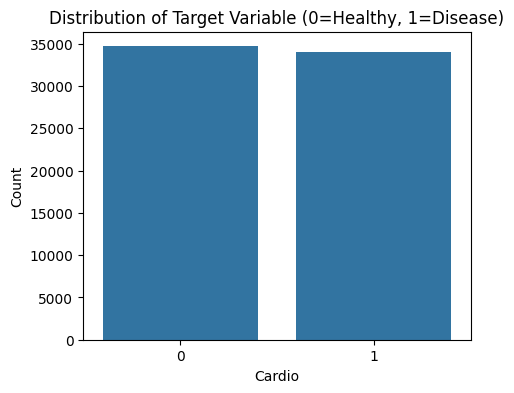

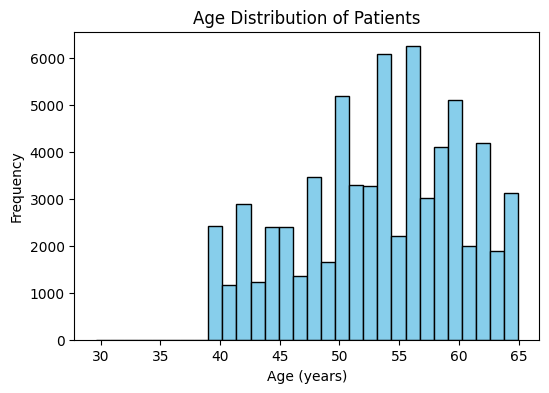

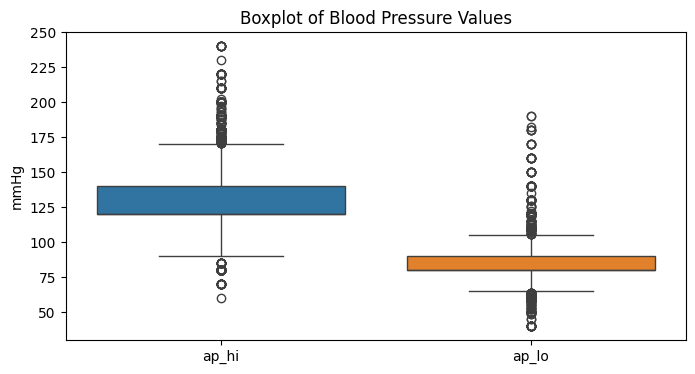

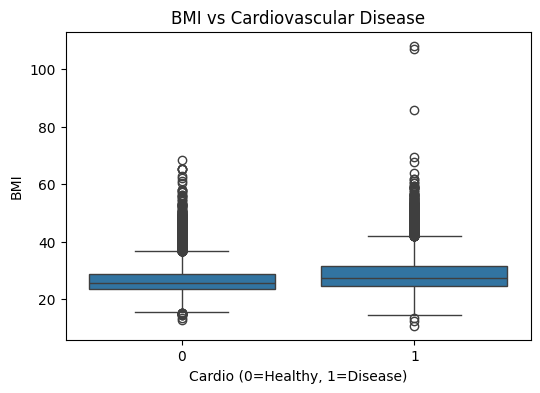

In [11]:
# I imported the matplotlib library to create data visualizations.
import matplotlib.pyplot as plt

# I imported the seaborn library to generate statistical graphs with improved visualization.
import seaborn as sns

# I created a count plot to visualize the distribution of the target variable.
plt.figure(figsize=(5,4))
sns.countplot(x='cardio', data=data)

# I added a title to clearly describe the chart.
plt.title("Distribution of Target Variable (0=Healthy, 1=Disease)")

# I labeled the x-axis to represent the target classes.
plt.xlabel("Cardio")

# I labeled the y-axis to represent the number of observations.
plt.ylabel("Count")

# I displayed the count plot.
plt.show()

# I converted age from days into years to improve readability and interpretation.
data['age_years'] = data['age'] / 365

# I created a new figure for the age distribution.
plt.figure(figsize=(6,4))

# I plotted a histogram to examine the distribution of patients' ages.
plt.hist(data['age_years'], bins=30, color='skyblue', edgecolor='black')

# I added a title to the histogram.
plt.title("Age Distribution of Patients")

# I labeled the x-axis to represent age in years.
plt.xlabel("Age (years)")

# I labeled the y-axis to represent the frequency of observations.
plt.ylabel("Frequency")

# I displayed the histogram.
plt.show()

# I created a new figure to visualize blood pressure values.
plt.figure(figsize=(8,4))

# I generated a boxplot to identify the distribution and outliers in systolic and diastolic blood pressure.
sns.boxplot(data=data[['ap_hi', 'ap_lo']])

# I added a title to the boxplot.
plt.title("Boxplot of Blood Pressure Values")

# I labeled the y-axis to indicate blood pressure measured in mmHg.
plt.ylabel("mmHg")

# I displayed the boxplot.
plt.show()

# I calculated the Body Mass Index (BMI) for each patient using height and weight.
data['BMI'] = data['weight'] / ((data['height'] / 100) ** 2)

# I created a new figure to examine the relationship between BMI and cardiovascular disease.
plt.figure(figsize=(6,4))

# I generated a boxplot to compare BMI across the target classes.
sns.boxplot(x='cardio', y='BMI', data=data)

# I added a title to describe the visualization.
plt.title("BMI vs Cardiovascular Disease")

# I labeled the x-axis to represent the target classes.
plt.xlabel("Cardio (0=Healthy, 1=Disease)")

# I labeled the y-axis to represent BMI values.
plt.ylabel("BMI")

# I displayed the boxplot.
plt.show()

# Data Pre Processing  and Splitting the Dataset 

In [12]:
# I imported the pandas library to perform data manipulation and preprocessing tasks.
import pandas as pd

# I imported the train_test_split function to divide the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

# I imported the LabelEncoder class to encode categorical variables into numerical values.
from sklearn.preprocessing import LabelEncoder

# I displayed the initial shape of the dataset before preprocessing.
print("Initial shape:", data.shape)

# I removed duplicate rows to improve the quality of the dataset.
data = data.drop_duplicates()

# I displayed the dataset shape after removing duplicate records.
print("Shape after removing duplicates:", data.shape)

# I checked for missing values before performing data cleaning.
print("\nMissing values before cleaning:")
print(data.isnull().sum())

# I identified all numerical columns in the dataset.
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# I filled missing numerical values with the median of each column using the imputation method.
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# I identified all categorical columns in the dataset.
cat_cols = data.select_dtypes(include=['object']).columns

# I filled missing categorical values with the most frequent value (mode) using the imputation method.
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# I displayed the missing values after completing the data cleaning process.
print("\nMissing values after cleaning:")
print(data.isnull().sum())

# I removed records with unreasonable systolic blood pressure values.
data = data[(data['ap_hi'] > 50) & (data['ap_hi'] < 250)]

# I removed records with unreasonable diastolic blood pressure values.
data = data[(data['ap_lo'] > 30) & (data['ap_lo'] < 200)]

# I removed records with unrealistic height values.
data = data[(data['height'] > 120) & (data['height'] < 220)]

# I removed records with unrealistic weight values.
data = data[(data['weight'] > 30) & (data['weight'] < 200)]

# I displayed the dataset shape after removing outliers.
print("\nShape after removing outliers:", data.shape)

# I created a LabelEncoder object to encode categorical variables if required.
encoder = LabelEncoder()

# I converted categorical variables into numerical values using label encoding.
for col in data.select_dtypes(include=['object']).columns:
    data[col] = encoder.fit_transform(data[col])

# I confirmed that the categorical encoding process had been completed.
print("\nCategorical encoding completed.")

# I defined the dependent (target) variable and independent variables.
target = 'cardio'
X = data.drop(columns=[target])
y = data[target]

# I split the dataset into training and testing sets using an 80:20 ratio while preserving class distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# I displayed the shape of the training dataset.
print("\nTraining set shape:", X_train.shape)

# I displayed the shape of the testing dataset.
print("Testing set shape:", X_test.shape)

# I confirmed that the data preprocessing process had been completed successfully.
print("\nData preprocessing completed successfully.")

Initial shape: (68682, 15)
Shape after removing duplicates: (68682, 15)

Missing values before cleaning:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
BMI            0
dtype: int64

Missing values after cleaning:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
BMI            0
dtype: int64

Shape after removing outliers: (68682, 15)

Categorical encoding completed.

Training set shape: (54945, 14)
Testing set shape: (13737, 14)

Data preprocessing completed successfully.


# Feature Engineering , Feature Importance &  Feature Scaling 

Feature engineering completed successfully.


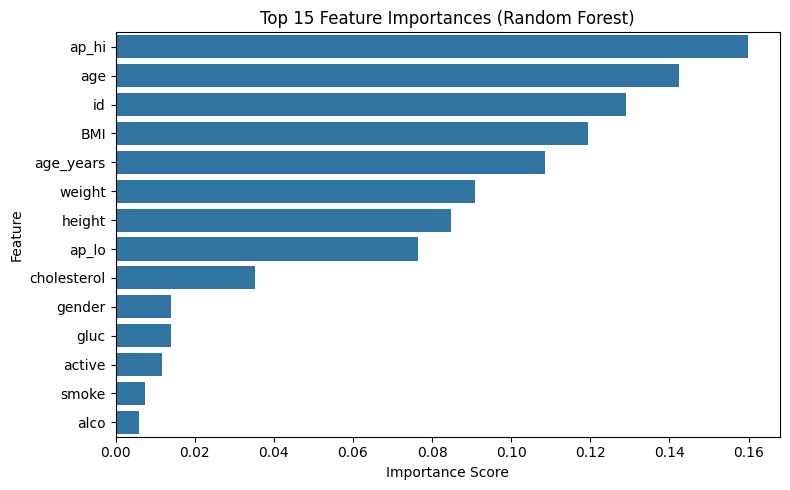


Top 15 Important Features:
ap_hi          0.159963
age            0.142429
id             0.129148
BMI            0.119334
age_years      0.108610
weight         0.090834
height         0.084888
ap_lo          0.076505
cholesterol    0.035316
gender         0.014111
gluc           0.013919
active         0.011650
smoke          0.007369
alco           0.005925
dtype: float64


In [13]:
# I imported the matplotlib library to create visualizations.
import matplotlib.pyplot as plt

# I imported the seaborn library to generate statistical plots.
import seaborn as sns

# I imported the StandardScaler class to standardize feature values.
from sklearn.preprocessing import StandardScaler

# I imported the RandomForestClassifier to evaluate feature importance.
from sklearn.ensemble import RandomForestClassifier

# I performed feature engineering to create additional meaningful features.

# I converted age from days to years in the training dataset.
X_train['age_years'] = (X_train['age'] / 365).round(1)

# I converted age from days to years in the testing dataset.
X_test['age_years'] = (X_test['age'] / 365).round(1)

# I calculated the Body Mass Index (BMI) for the training dataset.
X_train['BMI'] = X_train['weight'] / ((X_train['height'] / 100) ** 2)

# I calculated the Body Mass Index (BMI) for the testing dataset.
X_test['BMI'] = X_test['weight'] / ((X_test['height'] / 100) ** 2)

# I displayed a confirmation message after feature engineering.
print("Feature engineering completed successfully.")

# I created the Random Forest classifier for feature importance analysis.
rf_feature = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# I trained the Random Forest model using the unscaled training data.
rf_feature.fit(X_train, y_train)

# I extracted the feature importance scores.
importances = pd.Series(
    rf_feature.feature_importances_,
    index=X_train.columns
)

# I sorted the feature importance scores in descending order.
importances_sorted = importances.sort_values(ascending=False)

# I created a figure for the feature importance plot.
plt.figure(figsize=(8, 5))

# I plotted the top 15 most important features.
sns.barplot(
    x=importances_sorted.head(15),
    y=importances_sorted.head(15).index
)

# I added a title to the plot.
plt.title("Top 15 Feature Importances (Random Forest)")

# I labeled the x-axis.
plt.xlabel("Importance Score")

# I labeled the y-axis.
plt.ylabel("Feature")

# I adjusted the layout.
plt.tight_layout()

# I displayed the feature importance plot.
plt.show()

# I displayed the top 15 feature importance scores.
print("\nTop 15 Important Features:")
print(importances_sorted.head(15))

# I created a StandardScaler object.
scaler = StandardScaler()

# I fitted the scaler on the training data and transformed it.
X_train_scaled = scaler.fit_transform(X_train)

# I transformed the testing data using the fitted scaler.
X_test_scaled = scaler.transform(X_test)

# Model Selection and Training 

# Baseline Models (Before Hyper Parameter Tuning)

# Machine Learning Algorithms 

# Model 1 : Logistic Regression 

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Import the Logistic Regression algorithm.
from sklearn.linear_model import LogisticRegression

# Define the Baseline Logistic Regression model.
bas_lr_model = LogisticRegression(
    C=1.0,                  # Regularization strength.
    penalty='l2',           # L2 regularization.
    solver='lbfgs',         # Optimization algorithm.
    max_iter=1000,          # Maximum number of iterations.
    random_state=42         # Reproducible results.
)

# Train the Logistic Regression model.
bas_lr_model.fit(X_train_scaled, y_train)



# Generate predictions.
y_pred_bas_lr = bas_lr_model.predict(X_test_scaled)

# Generate prediction probabilities.
y_proba_bas_lr = bas_lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics.
bas_lr_accuracy = accuracy_score(y_test, y_pred_bas_lr)

bas_lr_precision = precision_score(
    y_test,
    y_pred_bas_lr,
    average="weighted"
)

bas_lr_recall = recall_score(
    y_test,
    y_pred_bas_lr,
    average="weighted"
)

bas_lr_f1 = f1_score(
    y_test,
    y_pred_bas_lr,
    average="weighted"
)

bas_lr_roc_auc = roc_auc_score(
    y_test,
    y_proba_bas_lr
)

# Generate confusion matrix.
bas_lr_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_bas_lr
)

# Generate classification report.
bas_lr_classification_report = classification_report(
    y_test,
    y_pred_bas_lr
)

# Generate ROC curve values.
bas_lr_fpr, bas_lr_tpr, bas_lr_thresholds = roc_curve(
    y_test,
    y_proba_bas_lr
)

# Store all evaluation results for later use.
bas_lr_metrics = {
    "Model": "Baseline Logistic Regression",
    "Accuracy": bas_lr_accuracy,
    "Precision": bas_lr_precision,
    "Recall": bas_lr_recall,
    "F1-Score": bas_lr_f1,
    "ROC-AUC": bas_lr_roc_auc,
    "Confusion Matrix": bas_lr_confusion_matrix,
    "Classification Report": bas_lr_classification_report,
    "FPR": bas_lr_fpr,
    "TPR": bas_lr_tpr,
    "Thresholds": bas_lr_thresholds,
    "Predictions": y_pred_bas_lr,
    "Probabilities": y_proba_bas_lr
}

# Display evaluation results.
print("\nBaseline Logistic Regression Performance")
print(f"Accuracy  : {bas_lr_accuracy:.4f}")
print(f"Precision : {bas_lr_precision:.4f}")
print(f"Recall    : {bas_lr_recall:.4f}")
print(f"F1-Score  : {bas_lr_f1:.4f}")
print(f"ROC-AUC   : {bas_lr_roc_auc:.4f}")

print("\nConfusion Matrix")
print(bas_lr_confusion_matrix)

print("\nClassification Report")
print(bas_lr_classification_report)


Baseline Logistic Regression Performance
Accuracy  : 0.7215
Precision : 0.7234
Recall    : 0.7215
F1-Score  : 0.7207
ROC-AUC   : 0.7867

Confusion Matrix
[[5364 1574]
 [2252 4547]]

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.77      0.74      6938
           1       0.74      0.67      0.70      6799

    accuracy                           0.72     13737
   macro avg       0.72      0.72      0.72     13737
weighted avg       0.72      0.72      0.72     13737



# Model 2 : LightGBM

In [16]:
# I imported the LightGBM classifier.
from lightgbm import LGBMClassifier

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# I defined the Baseline LightGBM model.
bas_lgbm_model = LGBMClassifier(
    boosting_type='gbdt',   # Gradient Boosting Decision Tree.
    objective='binary',     # Binary classification.
    n_estimators=100,       # Number of boosting iterations.
    learning_rate=0.1,      # Learning rate.
    num_leaves=31,          # Maximum number of leaves.
    max_depth=-1,           # Unlimited tree depth.
    random_state=42,        # Ensured reproducible results.
    verbosity=-1            # Suppressed training messages.
)

# I trained the LightGBM model.
bas_lgbm_model.fit(X_train, y_train)



# I generated predictions using the trained model.
y_pred_bas_lgbm = bas_lgbm_model.predict(X_test)

# I generated prediction probabilities.
y_proba_bas_lgbm = bas_lgbm_model.predict_proba(X_test)[:, 1]

# I calculated the model accuracy.
bas_lgbm_accuracy = accuracy_score(y_test, y_pred_bas_lgbm)

# I calculated the weighted precision.
bas_lgbm_precision = precision_score(
    y_test,
    y_pred_bas_lgbm,
    average="weighted"
)

# I calculated the weighted recall.
bas_lgbm_recall = recall_score(
    y_test,
    y_pred_bas_lgbm,
    average="weighted"
)

# I calculated the weighted F1-score.
bas_lgbm_f1 = f1_score(
    y_test,
    y_pred_bas_lgbm,
    average="weighted"
)

# I calculated the ROC-AUC score.
bas_lgbm_roc_auc = roc_auc_score(
    y_test,
    y_proba_bas_lgbm
)

# I generated the confusion matrix.
bas_lgbm_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_bas_lgbm
)

# I generated the classification report.
bas_lgbm_classification_report = classification_report(
    y_test,
    y_pred_bas_lgbm
)

# I generated the ROC curve values.
bas_lgbm_fpr, bas_lgbm_tpr, bas_lgbm_thresholds = roc_curve(
    y_test,
    y_proba_bas_lgbm
)

# I stored all evaluation metrics for later comparison.
bas_lgbm_metrics = {
    "Model": "Baseline LightGBM",
    "Accuracy": bas_lgbm_accuracy,
    "Precision": bas_lgbm_precision,
    "Recall": bas_lgbm_recall,
    "F1-Score": bas_lgbm_f1,
    "ROC-AUC": bas_lgbm_roc_auc,
    "Confusion Matrix": bas_lgbm_confusion_matrix,
    "Classification Report": bas_lgbm_classification_report,
    "FPR": bas_lgbm_fpr,
    "TPR": bas_lgbm_tpr,
    "Thresholds": bas_lgbm_thresholds,
    "Predictions": y_pred_bas_lgbm,
    "Probabilities": y_proba_bas_lgbm
}

# I displayed the evaluation results.
print("\nBaseline LightGBM Performance")

print(f"Accuracy  : {bas_lgbm_accuracy:.4f}")
print(f"Precision : {bas_lgbm_precision:.4f}")
print(f"Recall    : {bas_lgbm_recall:.4f}")
print(f"F1-Score  : {bas_lgbm_f1:.4f}")
print(f"ROC-AUC   : {bas_lgbm_roc_auc:.4f}")

print("\nConfusion Matrix")
print(bas_lgbm_confusion_matrix)

print("\nClassification Report")
print(bas_lgbm_classification_report)


Baseline LightGBM Performance
Accuracy  : 0.7307
Precision : 0.7315
Recall    : 0.7307
F1-Score  : 0.7304
ROC-AUC   : 0.7975

Confusion Matrix
[[5312 1626]
 [2073 4726]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6938
           1       0.74      0.70      0.72      6799

    accuracy                           0.73     13737
   macro avg       0.73      0.73      0.73     13737
weighted avg       0.73      0.73      0.73     13737



# Model 3 : CatBoost 

In [17]:
# I imported the CatBoost classifier.
from catboost import CatBoostClassifier

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# I defined the Baseline CatBoost model.
bas_cat_model = CatBoostClassifier(
    iterations=100,         # Number of boosting iterations.
    learning_rate=0.1,      # Learning rate.
    depth=6,                # Depth of each decision tree.
    loss_function='Logloss',# Loss function for binary classification.
    eval_metric='AUC',      # Evaluation metric.
    random_seed=42,         # Ensured reproducible results.
    verbose=False           # Suppressed training output.
)

# I trained the CatBoost model.
bas_cat_model.fit(X_train, y_train)



# I generated predictions using the trained model.
y_pred_bas_cat = bas_cat_model.predict(X_test)

# I generated prediction probabilities.
y_proba_bas_cat = bas_cat_model.predict_proba(X_test)[:, 1]

# I calculated the model accuracy.
bas_cat_accuracy = accuracy_score(y_test, y_pred_bas_cat)

# I calculated the weighted precision.
bas_cat_precision = precision_score(
    y_test,
    y_pred_bas_cat,
    average="weighted"
)

# I calculated the weighted recall.
bas_cat_recall = recall_score(
    y_test,
    y_pred_bas_cat,
    average="weighted"
)

# I calculated the weighted F1-score.
bas_cat_f1 = f1_score(
    y_test,
    y_pred_bas_cat,
    average="weighted"
)

# I calculated the ROC-AUC score.
bas_cat_roc_auc = roc_auc_score(
    y_test,
    y_proba_bas_cat
)

# I generated the confusion matrix.
bas_cat_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_bas_cat
)

# I generated the classification report.
bas_cat_classification_report = classification_report(
    y_test,
    y_pred_bas_cat
)

# I generated the ROC curve values.
bas_cat_fpr, bas_cat_tpr, bas_cat_thresholds = roc_curve(
    y_test,
    y_proba_bas_cat
)

# I stored all evaluation metrics for later comparison.
bas_cat_metrics = {
    "Model": "Baseline CatBoost",
    "Accuracy": bas_cat_accuracy,
    "Precision": bas_cat_precision,
    "Recall": bas_cat_recall,
    "F1-Score": bas_cat_f1,
    "ROC-AUC": bas_cat_roc_auc,
    "Confusion Matrix": bas_cat_confusion_matrix,
    "Classification Report": bas_cat_classification_report,
    "FPR": bas_cat_fpr,
    "TPR": bas_cat_tpr,
    "Thresholds": bas_cat_thresholds,
    "Predictions": y_pred_bas_cat,
    "Probabilities": y_proba_bas_cat
}

# I displayed the evaluation results.
print("\nBaseline CatBoost Performance")

print(f"Accuracy  : {bas_cat_accuracy:.4f}")
print(f"Precision : {bas_cat_precision:.4f}")
print(f"Recall    : {bas_cat_recall:.4f}")
print(f"F1-Score  : {bas_cat_f1:.4f}")
print(f"ROC-AUC   : {bas_cat_roc_auc:.4f}")

print("\nConfusion Matrix")
print(bas_cat_confusion_matrix)

print("\nClassification Report")
print(bas_cat_classification_report)


Baseline CatBoost Performance
Accuracy  : 0.7307
Precision : 0.7317
Recall    : 0.7307
F1-Score  : 0.7303
ROC-AUC   : 0.7983

Confusion Matrix
[[5327 1611]
 [2088 4711]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6938
           1       0.75      0.69      0.72      6799

    accuracy                           0.73     13737
   macro avg       0.73      0.73      0.73     13737
weighted avg       0.73      0.73      0.73     13737



# Deep Learning Algorithm 

# Model 4 : Artificial Neural Network 

In [18]:
# I imported the required TensorFlow libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# I imported the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# I defined the Baseline Artificial Neural Network model.
bas_ann_model = Sequential()

# I added the input layer and first hidden layer.
bas_ann_model.add(Dense(
    units=64,
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

# I added the second hidden layer.
bas_ann_model.add(Dense(
    units=32,
    activation='relu'
))

# I added the output layer.
bas_ann_model.add(Dense(
    units=1,
    activation='sigmoid'
))

# I compiled the ANN model.
bas_ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# I trained the ANN model.
bas_ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# I generated prediction probabilities.
y_proba_bas_ann = bas_ann_model.predict(X_test_scaled)

# I converted probabilities into class labels.
y_pred_bas_ann = (y_proba_bas_ann >= 0.5).astype(int).flatten()

# I flattened the probability array.
y_proba_bas_ann = y_proba_bas_ann.flatten()

# I calculated the model accuracy.
bas_ann_accuracy = accuracy_score(
    y_test,
    y_pred_bas_ann
)

# I calculated the weighted precision.
bas_ann_precision = precision_score(
    y_test,
    y_pred_bas_ann,
    average="weighted"
)

# I calculated the weighted recall.
bas_ann_recall = recall_score(
    y_test,
    y_pred_bas_ann,
    average="weighted"
)

# I calculated the weighted F1-score.
bas_ann_f1 = f1_score(
    y_test,
    y_pred_bas_ann,
    average="weighted"
)

# I calculated the ROC-AUC score.
bas_ann_roc_auc = roc_auc_score(
    y_test,
    y_proba_bas_ann
)

# I generated the confusion matrix.
bas_ann_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_bas_ann
)

# I generated the classification report.
bas_ann_classification_report = classification_report(
    y_test,
    y_pred_bas_ann
)

# I generated the ROC curve values.
bas_ann_fpr, bas_ann_tpr, bas_ann_thresholds = roc_curve(
    y_test,
    y_proba_bas_ann
)

# I stored all evaluation metrics for later comparison.
bas_ann_metrics = {
    "Model": "Baseline ANN",
    "Accuracy": bas_ann_accuracy,
    "Precision": bas_ann_precision,
    "Recall": bas_ann_recall,
    "F1-Score": bas_ann_f1,
    "ROC-AUC": bas_ann_roc_auc,
    "Confusion Matrix": bas_ann_confusion_matrix,
    "Classification Report": bas_ann_classification_report,
    "FPR": bas_ann_fpr,
    "TPR": bas_ann_tpr,
    "Thresholds": bas_ann_thresholds,
    "Predictions": y_pred_bas_ann,
    "Probabilities": y_proba_bas_ann
}

# I displayed the evaluation results.
print("\nBaseline ANN Performance")

print(f"Accuracy  : {bas_ann_accuracy:.4f}")
print(f"Precision : {bas_ann_precision:.4f}")
print(f"Recall    : {bas_ann_recall:.4f}")
print(f"F1-Score  : {bas_ann_f1:.4f}")
print(f"ROC-AUC   : {bas_ann_roc_auc:.4f}")

print("\nConfusion Matrix")
print(bas_ann_confusion_matrix)

print("\nClassification Report")
print(bas_ann_classification_report)

Epoch 1/50
1374/1374 [==============================] - 11s 6ms/step - loss: 0.5575 - accuracy: 0.7232 - val_loss: 0.5449 - val_accuracy: 0.7325
Epoch 2/50
1374/1374 [==============================] - 8s 6ms/step - loss: 0.5472 - accuracy: 0.7318 - val_loss: 0.5427 - val_accuracy: 0.7348
Epoch 3/50
1374/1374 [==============================] - 8s 6ms/step - loss: 0.5448 - accuracy: 0.7342 - val_loss: 0.5421 - val_accuracy: 0.7358
Epoch 4/50
1374/1374 [==============================] - 8s 5ms/step - loss: 0.5435 - accuracy: 0.7336 - val_loss: 0.5407 - val_accuracy: 0.7364
Epoch 5/50
1374/1374 [==============================] - 7s 5ms/step - loss: 0.5426 - accuracy: 0.7333 - val_loss: 0.5401 - val_accuracy: 0.7361
Epoch 6/50
1374/1374 [==============================] - 7s 5ms/step - loss: 0.5414 - accuracy: 0.7350 - val_loss: 0.5400 - val_accuracy: 0.7396
Epoch 7/50
1374/1374 [==============================] - 7s 5ms/step - loss: 0.5407 - accuracy: 0.7359 - val_loss: 0.5413 - val_accuracy

# Combined Comparative Table for all Baseline Models 

In [25]:
# Import the pandas library.
import pandas as pd

# Create a comparative table.
baseline_results = pd.DataFrame([

    {
        "Model": bas_lr_metrics["Model"],
        "Accuracy": bas_lr_metrics["Accuracy"],
        "Precision": bas_lr_metrics["Precision"],
        "Recall": bas_lr_metrics["Recall"],
        "F1-Score": bas_lr_metrics["F1-Score"],
        "ROC-AUC": bas_lr_metrics["ROC-AUC"]
    },

    {
        "Model": bas_lgbm_metrics["Model"],
        "Accuracy": bas_lgbm_metrics["Accuracy"],
        "Precision": bas_lgbm_metrics["Precision"],
        "Recall": bas_lgbm_metrics["Recall"],
        "F1-Score": bas_lgbm_metrics["F1-Score"],
        "ROC-AUC": bas_lgbm_metrics["ROC-AUC"]
    },

    {
        "Model": bas_cat_metrics["Model"],
        "Accuracy": bas_cat_metrics["Accuracy"],
        "Precision": bas_cat_metrics["Precision"],
        "Recall": bas_cat_metrics["Recall"],
        "F1-Score": bas_cat_metrics["F1-Score"],
        "ROC-AUC": bas_cat_metrics["ROC-AUC"]
    },

    {
        "Model": bas_ann_metrics["Model"],
        "Accuracy": bas_ann_metrics["Accuracy"],
        "Precision": bas_ann_metrics["Precision"],
        "Recall": bas_ann_metrics["Recall"],
        "F1-Score": bas_ann_metrics["F1-Score"],
        "ROC-AUC": bas_ann_metrics["ROC-AUC"]
    }

])

# Round the values.
baseline_results.iloc[:,1:] = baseline_results.iloc[:,1:].round(4)

# Assign a different background color to each model.
row_colors = [
    "background-color:#D6EAF8;",   # Logistic Regression - Light Blue
    "background-color:#D5F5E3;",   # LightGBM - Light Green
    "background-color:#FCF3CF;",   # CatBoost - Light Yellow
    "background-color:#FADBD8;"    # ANN - Light Red
]

def color_rows(row):
    return [row_colors[row.name]] * len(row)

# Display the styled table.
display(

    baseline_results.style

    .apply(color_rows, axis=1)

    .set_properties(**{
        "text-align":"center",
        "border":"1px solid black",
        "font-size":"13px"
    })

    .set_table_styles([
        {
            "selector":"th",
            "props":[
                ("background-color","#003366"),
                ("color","white"),
                ("font-size","14px"),
                ("font-weight","bold"),
                ("text-align","center"),
                ("border","2px solid white")
            ]
        },
        {
            "selector":"caption",
            "props":[
                ("caption-side","top"),
                ("font-size","18px"),
                ("font-weight","bold"),
                ("color","#003366")
            ]
        }
    ])

    .set_caption("Comparative Performance of Baseline Models")

)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.721500,0.723400,0.721500,0.720700,0.786700
1,Baseline LightGBM,0.730700,0.731500,0.730700,0.730400,0.797500
2,Baseline CatBoost,0.730700,0.731700,0.730700,0.730300,0.798300
3,Baseline ANN,0.724700,0.725100,0.724700,0.724400,0.788100


# Each Metric Graph for all Baseline Models 

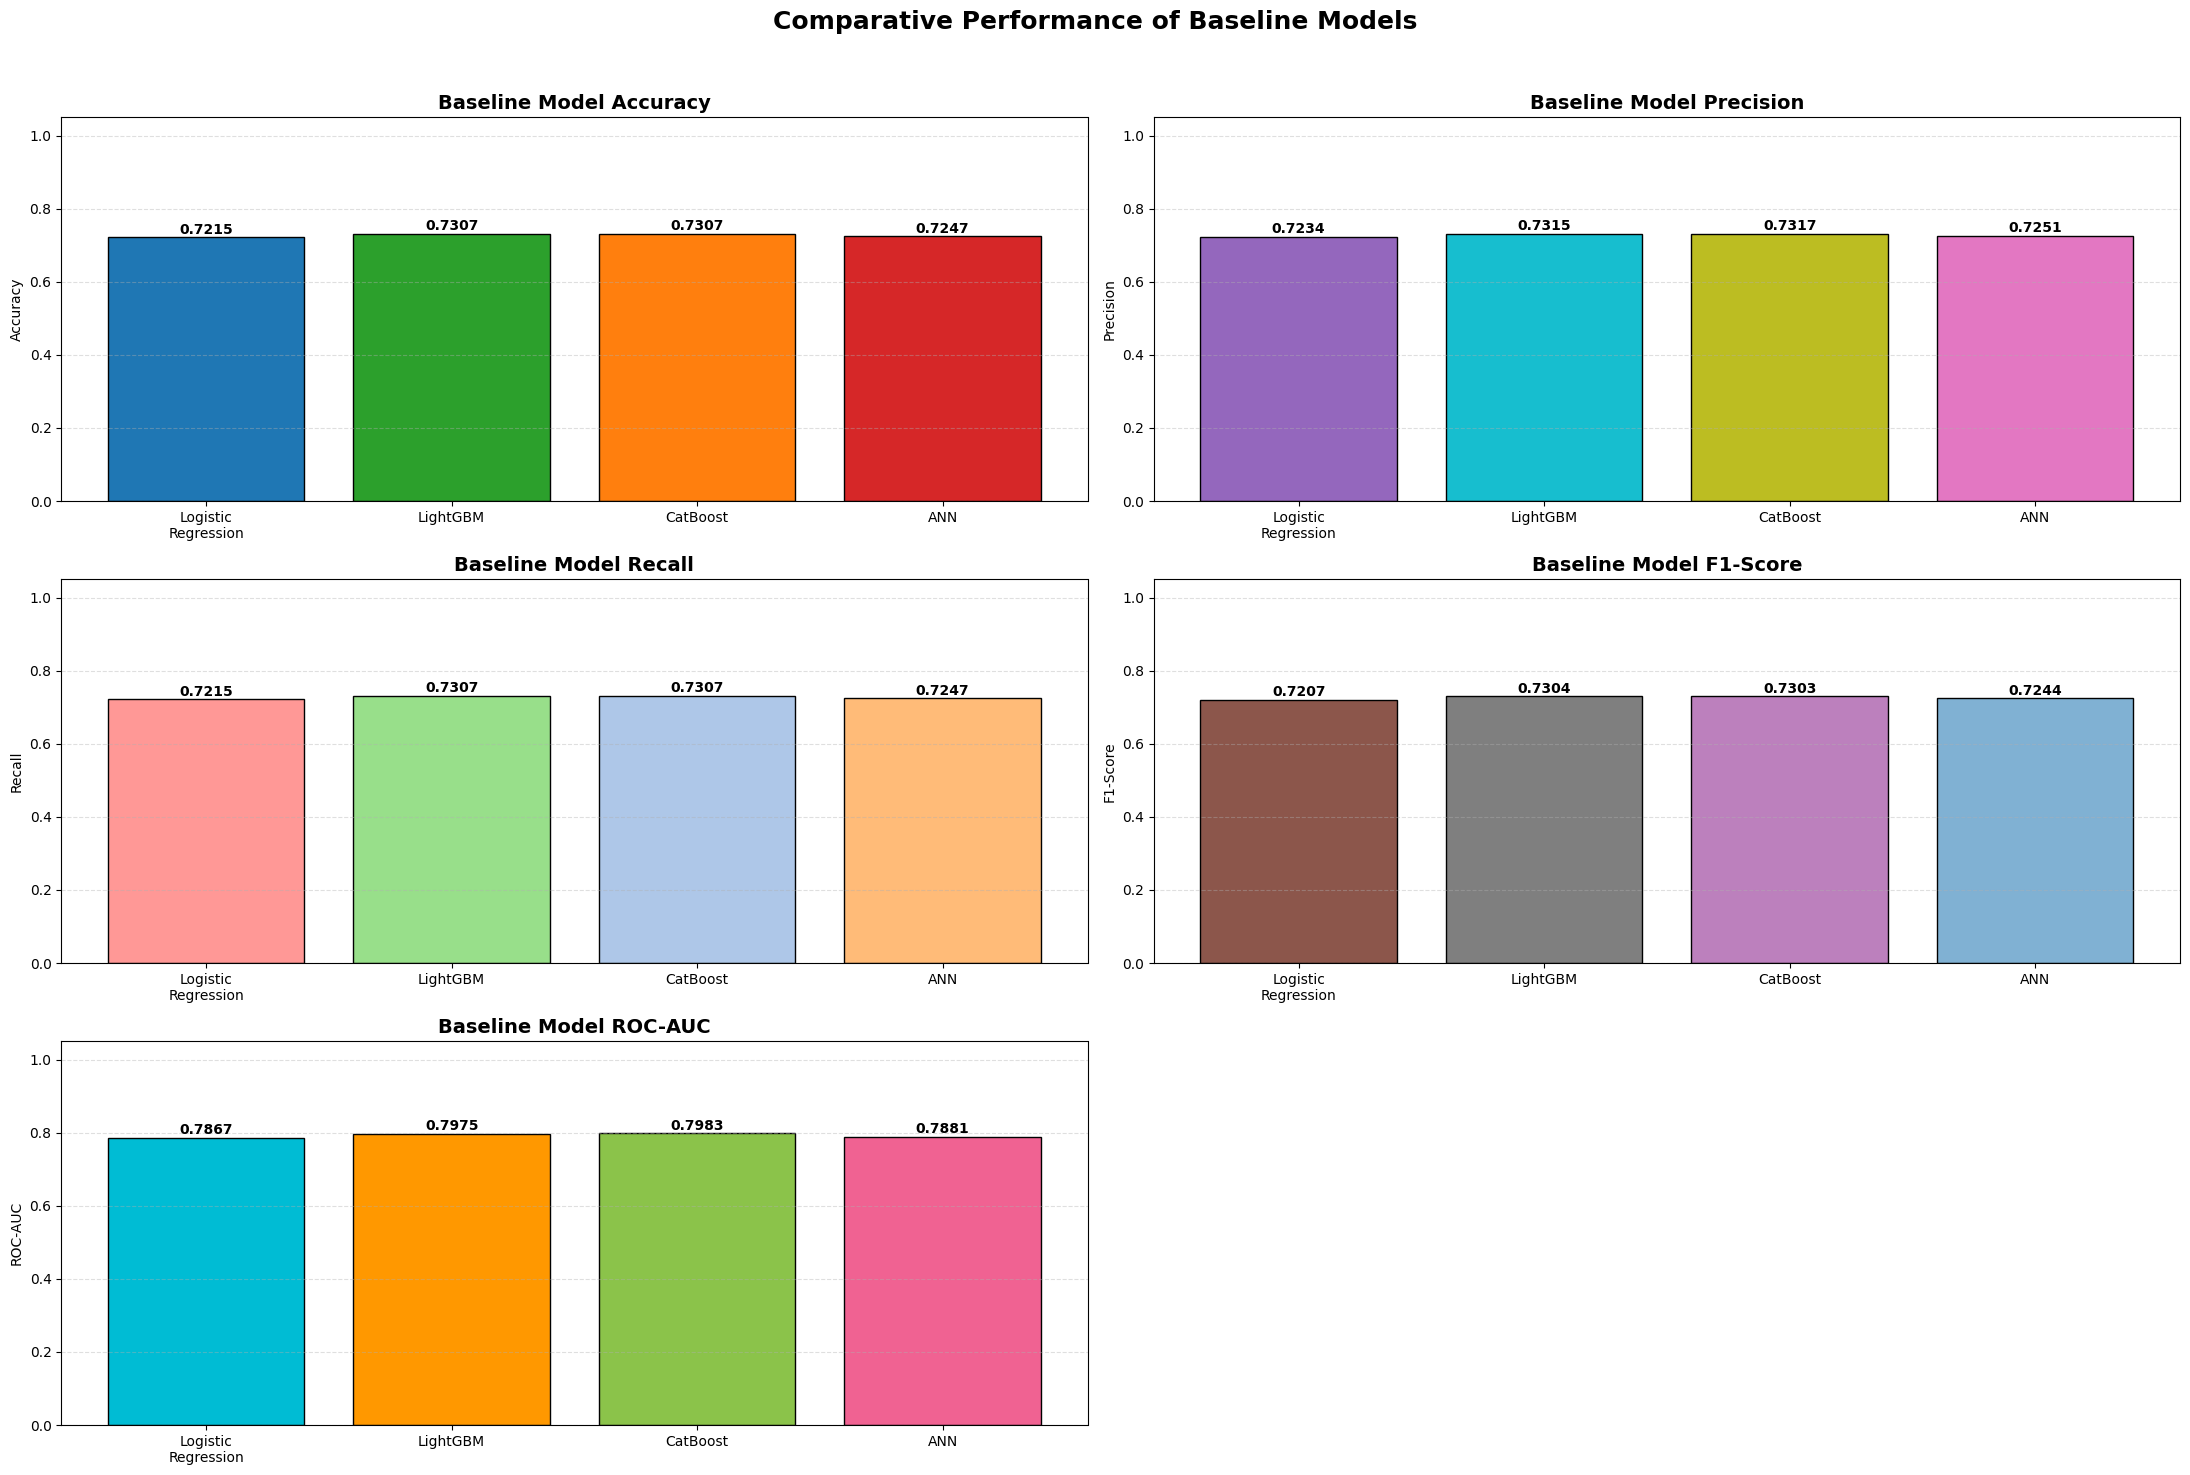

In [21]:
# Import the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# Store the model names.
models = [
    "Logistic\nRegression",
    "LightGBM",
    "CatBoost",
    "ANN"
]

# Store the evaluation metrics.
accuracy = [
    bas_lr_metrics["Accuracy"],
    bas_lgbm_metrics["Accuracy"],
    bas_cat_metrics["Accuracy"],
    bas_ann_metrics["Accuracy"]
]

precision = [
    bas_lr_metrics["Precision"],
    bas_lgbm_metrics["Precision"],
    bas_cat_metrics["Precision"],
    bas_ann_metrics["Precision"]
]

recall = [
    bas_lr_metrics["Recall"],
    bas_lgbm_metrics["Recall"],
    bas_cat_metrics["Recall"],
    bas_ann_metrics["Recall"]
]

f1_score_values = [
    bas_lr_metrics["F1-Score"],
    bas_lgbm_metrics["F1-Score"],
    bas_cat_metrics["F1-Score"],
    bas_ann_metrics["F1-Score"]
]

roc_auc = [
    bas_lr_metrics["ROC-AUC"],
    bas_lgbm_metrics["ROC-AUC"],
    bas_cat_metrics["ROC-AUC"],
    bas_ann_metrics["ROC-AUC"]
]

# Create the figure.
plt.figure(figsize=(22, 15))

# Accuracy Graph
plt.subplot(3, 2, 1)
bars = plt.bar(models, accuracy,
               color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"],
               edgecolor="black")
plt.title("Baseline Model Accuracy", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Precision Graph
plt.subplot(3, 2, 2)
bars = plt.bar(models, precision,
               color=["#9467bd", "#17becf", "#bcbd22", "#e377c2"],
               edgecolor="black")
plt.title("Baseline Model Precision", fontsize=14, fontweight="bold")
plt.ylabel("Precision")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Recall Graph
plt.subplot(3, 2, 3)
bars = plt.bar(models, recall,
               color=["#ff9896", "#98df8a", "#aec7e8", "#ffbb78"],
               edgecolor="black")
plt.title("Baseline Model Recall", fontsize=14, fontweight="bold")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# F1-Score Graph
plt.subplot(3, 2, 4)
bars = plt.bar(models, f1_score_values,
               color=["#8c564b", "#7f7f7f", "#bc80bd", "#80b1d3"],
               edgecolor="black")
plt.title("Baseline Model F1-Score", fontsize=14, fontweight="bold")
plt.ylabel("F1-Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ROC-AUC Graph
plt.subplot(3, 2, 5)
bars = plt.bar(models, roc_auc,
               color=["#00bcd4", "#ff9800", "#8bc34a", "#f06292"],
               edgecolor="black")
plt.title("Baseline Model ROC-AUC", fontsize=14, fontweight="bold")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Hide the unused subplot.
plt.subplot(3, 2, 6)
plt.axis("off")

# Add an overall title.
plt.suptitle(
    "Comparative Performance of Baseline Models",
    fontsize=18,
    fontweight="bold"
)

# Adjust layout.
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the graphs.
plt.show()

# Combined F1-Score graph for all Baseline Models 

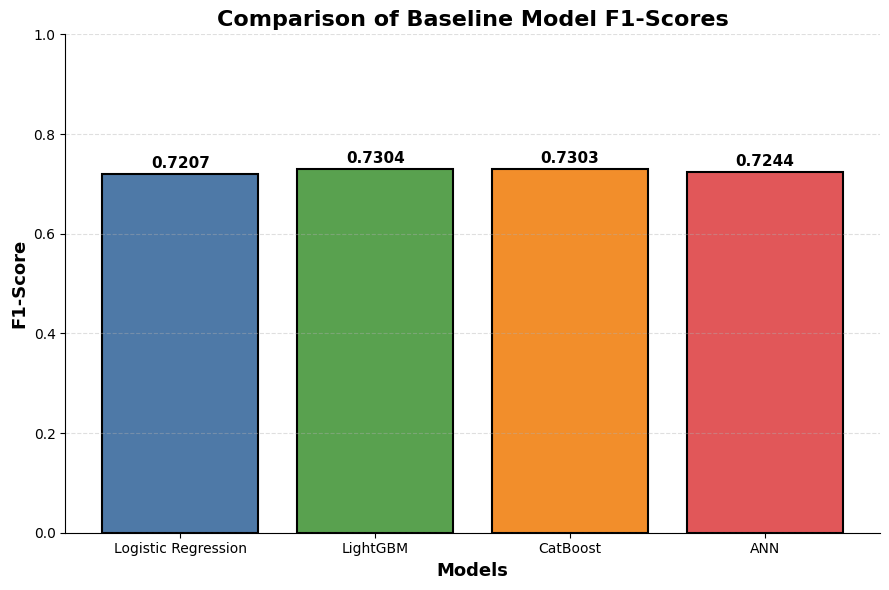

In [26]:
# Import the required library.
import matplotlib.pyplot as plt

# Store the model names.
models = [
    "Logistic Regression",
    "LightGBM",
    "CatBoost",
    "ANN"
]

# Store the F1-Score values.
f1_scores = [
    bas_lr_metrics["F1-Score"],
    bas_lgbm_metrics["F1-Score"],
    bas_cat_metrics["F1-Score"],
    bas_ann_metrics["F1-Score"]
]

# Define different colors for each model.
colors = [
    "#4E79A7",   # Blue
    "#59A14F",   # Green
    "#F28E2B",   # Orange
    "#E15759"    # Red
]

# Create the figure.
plt.figure(figsize=(9,6))

# Create the bar chart.
bars = plt.bar(
    models,
    f1_scores,
    color=colors,
    edgecolor="black",
    linewidth=1.5
)

# Add value labels above each bar.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Customize the graph.
plt.title(
    "Comparison of Baseline Model F1-Scores",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Models",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "F1-Score",
    fontsize=13,
    fontweight="bold"
)

plt.ylim(0, 1.0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Remove the top and right borders.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Display the graph.
plt.tight_layout()
plt.show()

# Combined Comparative Bar Graph for all Baseline Models 

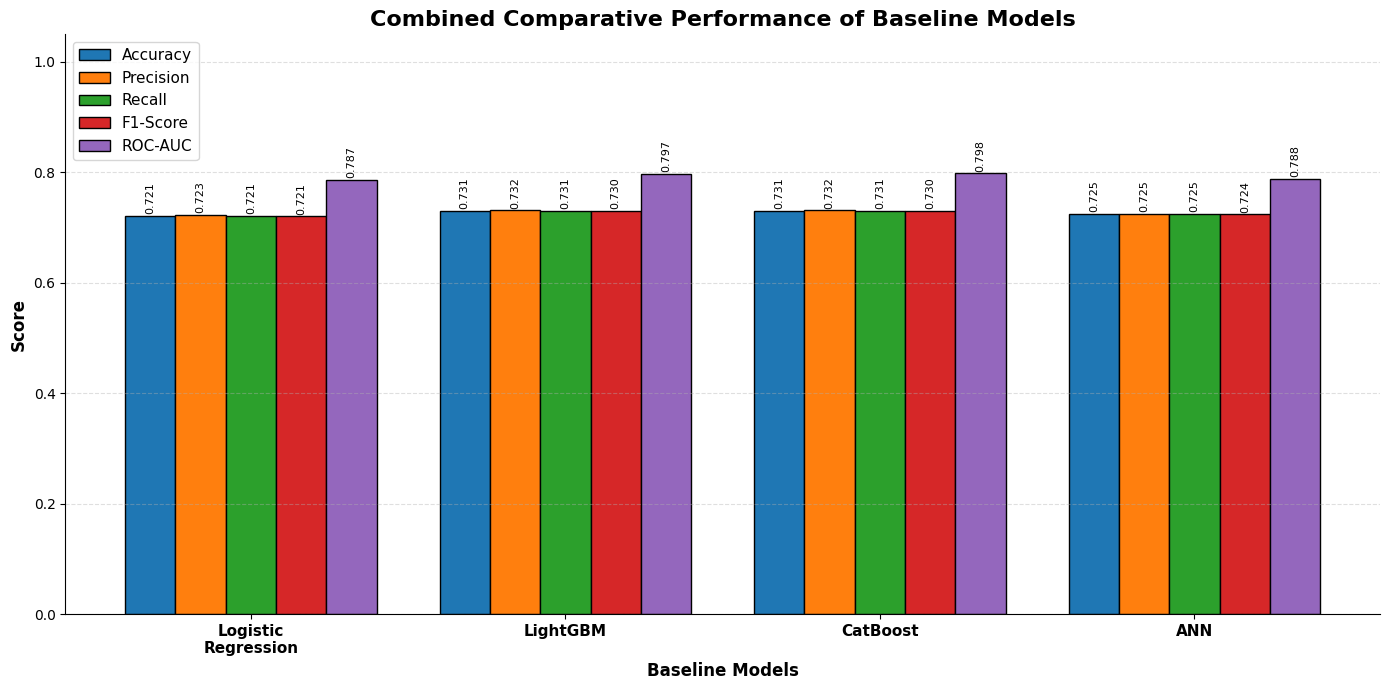

In [27]:
# Import the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# Store the model names.
models = [
    "Logistic\nRegression",
    "LightGBM",
    "CatBoost",
    "ANN"
]

# Store all evaluation metrics.
accuracy = [
    bas_lr_metrics["Accuracy"],
    bas_lgbm_metrics["Accuracy"],
    bas_cat_metrics["Accuracy"],
    bas_ann_metrics["Accuracy"]
]

precision = [
    bas_lr_metrics["Precision"],
    bas_lgbm_metrics["Precision"],
    bas_cat_metrics["Precision"],
    bas_ann_metrics["Precision"]
]

recall = [
    bas_lr_metrics["Recall"],
    bas_lgbm_metrics["Recall"],
    bas_cat_metrics["Recall"],
    bas_ann_metrics["Recall"]
]

f1_score = [
    bas_lr_metrics["F1-Score"],
    bas_lgbm_metrics["F1-Score"],
    bas_cat_metrics["F1-Score"],
    bas_ann_metrics["F1-Score"]
]

roc_auc = [
    bas_lr_metrics["ROC-AUC"],
    bas_lgbm_metrics["ROC-AUC"],
    bas_cat_metrics["ROC-AUC"],
    bas_ann_metrics["ROC-AUC"]
]

# Set the x-axis locations.
x = np.arange(len(models))

# Set the width of each bar.
width = 0.16

# Create the figure.
plt.figure(figsize=(14,7))

# Plot each metric.
bars1 = plt.bar(x - 2*width, accuracy, width,
                label="Accuracy",
                color="#1f77b4",
                edgecolor="black")

bars2 = plt.bar(x - width, precision, width,
                label="Precision",
                color="#ff7f0e",
                edgecolor="black")

bars3 = plt.bar(x, recall, width,
                label="Recall",
                color="#2ca02c",
                edgecolor="black")

bars4 = plt.bar(x + width, f1_score, width,
                label="F1-Score",
                color="#d62728",
                edgecolor="black")

bars5 = plt.bar(x + 2*width, roc_auc, width,
                label="ROC-AUC",
                color="#9467bd",
                edgecolor="black")

# Add value labels.
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

# Customize the graph.
plt.xticks(x, models, fontsize=11, fontweight="bold")
plt.ylabel("Score", fontsize=12, fontweight="bold")
plt.xlabel("Baseline Models", fontsize=12, fontweight="bold")
plt.title(
    "Combined Comparative Performance of Baseline Models",
    fontsize=16,
    fontweight="bold"
)

plt.ylim(0, 1.05)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    fontsize=11,
    loc="upper left",
    frameon=True
)

# Remove unnecessary borders.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

# Confusion Matrices for all Baseline Models 

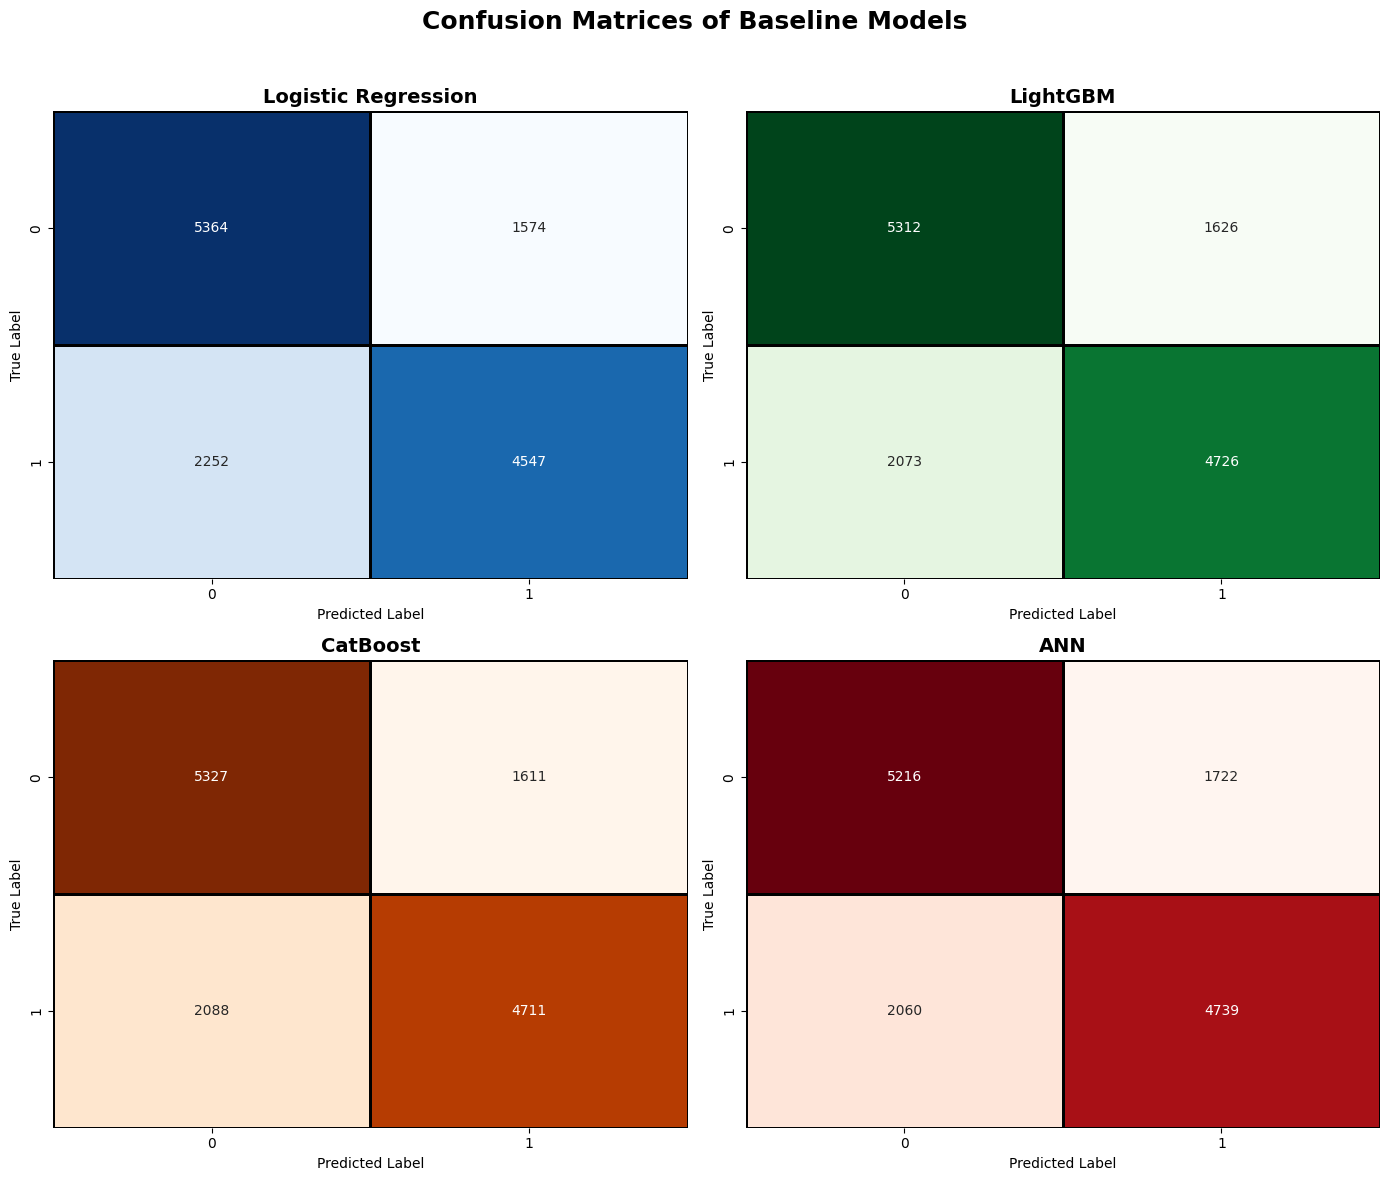

In [28]:
# Import the required libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for all confusion matrices.
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Logistic Regression
sns.heatmap(
    bas_lr_metrics["Confusion Matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="black",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Logistic Regression", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Predicted Label")
axes[0, 0].set_ylabel("True Label")

# LightGBM
sns.heatmap(
    bas_lgbm_metrics["Confusion Matrix"],
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    linewidths=1,
    linecolor="black",
    ax=axes[0, 1]
)
axes[0, 1].set_title("LightGBM", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Predicted Label")
axes[0, 1].set_ylabel("True Label")

# CatBoost
sns.heatmap(
    bas_cat_metrics["Confusion Matrix"],
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    linewidths=1,
    linecolor="black",
    ax=axes[1, 0]
)
axes[1, 0].set_title("CatBoost", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Predicted Label")
axes[1, 0].set_ylabel("True Label")

# ANN
sns.heatmap(
    bas_ann_metrics["Confusion Matrix"],
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    linewidths=1,
    linecolor="black",
    ax=axes[1, 1]
)
axes[1, 1].set_title("ANN", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Predicted Label")
axes[1, 1].set_ylabel("True Label")

# Add an overall title.
plt.suptitle(
    "Confusion Matrices of Baseline Models",
    fontsize=18,
    fontweight="bold"
)

# Adjust the layout.
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the confusion matrices.
plt.show()

# Combined AUC-ROC Curve for all Baseline Models 

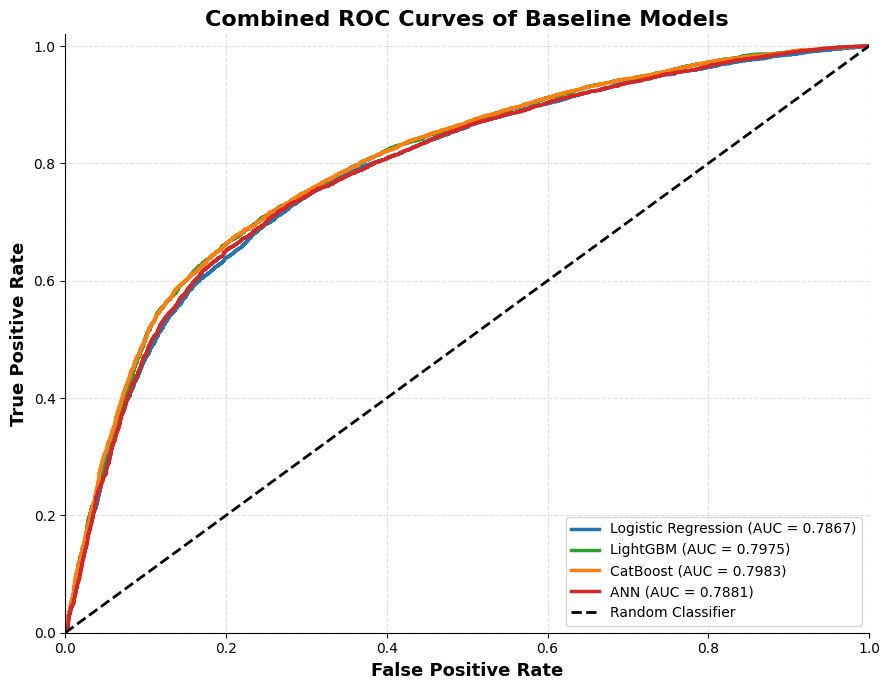

In [29]:
# Import the required libraries.
import matplotlib.pyplot as plt

# Create the figure.
plt.figure(figsize=(9, 7))

# Plot the ROC curve for Logistic Regression.
plt.plot(
    bas_lr_metrics["FPR"],
    bas_lr_metrics["TPR"],
    color="#1f77b4",
    linewidth=2.5,
    label=f'Logistic Regression (AUC = {bas_lr_metrics["ROC-AUC"]:.4f})'
)

# Plot the ROC curve for LightGBM.
plt.plot(
    bas_lgbm_metrics["FPR"],
    bas_lgbm_metrics["TPR"],
    color="#2ca02c",
    linewidth=2.5,
    label=f'LightGBM (AUC = {bas_lgbm_metrics["ROC-AUC"]:.4f})'
)

# Plot the ROC curve for CatBoost.
plt.plot(
    bas_cat_metrics["FPR"],
    bas_cat_metrics["TPR"],
    color="#ff7f0e",
    linewidth=2.5,
    label=f'CatBoost (AUC = {bas_cat_metrics["ROC-AUC"]:.4f})'
)

# Plot the ROC curve for ANN.
plt.plot(
    bas_ann_metrics["FPR"],
    bas_ann_metrics["TPR"],
    color="#d62728",
    linewidth=2.5,
    label=f'ANN (AUC = {bas_ann_metrics["ROC-AUC"]:.4f})'
)

# Plot the random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

# Customize the graph.
plt.title(
    "Combined ROC Curves of Baseline Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.xlim([0, 1])
plt.ylim([0, 1.02])

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

# Remove unnecessary borders.
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Display the ROC curves.
plt.tight_layout()
plt.show()

# Hyper Parameter Tuning 

# Model 1 : Tuned Logistic Regression

In [30]:
# Import the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Define the Logistic Regression model.
lr = LogisticRegression(
    random_state=42,
    max_iter=2000
)

# Define the hyperparameter search space.
lr_param_grid = {

    "C": [0.1, 1, 10],

    "penalty": ["l2"],

    "solver": ["lbfgs"]

}

# Perform Grid Search Cross Validation.
lr_grid_search = GridSearchCV(

    estimator=lr,

    param_grid=lr_param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1,

    verbose=2

)

# Train the model.
lr_grid_search.fit(X_train_scaled, y_train)

# Display the best hyperparameters.
print("\nBest Hyperparameters")
print(lr_grid_search.best_params_)

# Display the best cross-validation score.
print("\nBest Cross Validation F1-Score")
print(round(lr_grid_search.best_score_, 4))

# Store the best model.
best_lr = lr_grid_search.best_estimator_

# Predict on the testing data.
y_pred = best_lr.predict(X_test_scaled)

# Predict probabilities.
y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Print the evaluation metrics.
print("\nOptimized Logistic Regression Performance")


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(conf_matrix)

print("\nClassification Report")
print(class_report)

# Store all evaluation metrics.
tuned_lr_metrics = {

    "Model": "Logistic Regression",

    "Best Parameters": lr_grid_search.best_params_,

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1-Score": f1,

    "ROC-AUC": roc_auc,

    "Confusion Matrix": conf_matrix,

    "Classification Report": class_report,

    "FPR": fpr,

    "TPR": tpr,

    "Thresholds": thresholds,

    "Predictions": y_pred,

    "Probabilities": y_prob

}

Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Hyperparameters
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation F1-Score
0.7095

Optimized Logistic Regression Performance
Accuracy  : 0.7215
Precision : 0.7429
Recall    : 0.6688
F1-Score  : 0.7039
ROC-AUC   : 0.7867

Confusion Matrix
[[5364 1574]
 [2252 4547]]

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.77      0.74      6938
           1       0.74      0.67      0.70      6799

    accuracy                           0.72     13737
   macro avg       0.72      0.72      0.72     13737
weighted avg       0.72      0.72      0.72     13737



# Model 2 : Tuned LightGBM

In [31]:
# Import the required libraries.
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Define the LightGBM model.
lgbm = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# Define the hyperparameter search space.
lgbm_param_grid = {

    "n_estimators": [100, 200],

    "learning_rate": [0.05, 0.1],

    "max_depth": [5, 7],

    "num_leaves": [31, 50]

}

# Perform Grid Search Cross Validation.
lgbm_grid_search = GridSearchCV(

    estimator=lgbm,

    param_grid=lgbm_param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1,

    verbose=2

)

# Train the model.
lgbm_grid_search.fit(X_train, y_train)

# Display the best hyperparameters.
print("\nBest Hyperparameters")
print(lgbm_grid_search.best_params_)

# Display the best cross-validation score.
print("\nBest Cross Validation F1-Score")
print(round(lgbm_grid_search.best_score_, 4))

# Store the best model.
best_lgbm = lgbm_grid_search.best_estimator_

# Predict on the testing data.
y_pred = best_lgbm.predict(X_test)

# Predict probabilities.
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Print the evaluation metrics.
print("\nOptimized LightGBM Performance")
print("-" * 40)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(conf_matrix)

print("\nClassification Report")
print(class_report)

# Store all evaluation metrics.
tuned_lgbm_metrics = {

    "Model": "LightGBM",

    "Best Parameters": lgbm_grid_search.best_params_,

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1-Score": f1,

    "ROC-AUC": roc_auc,

    "Confusion Matrix": conf_matrix,

    "Classification Report": class_report,

    "FPR": fpr,

    "TPR": tpr,

    "Thresholds": thresholds,

    "Predictions": y_pred,

    "Probabilities": y_prob

}

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Hyperparameters
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'num_leaves': 31}

Best Cross Validation F1-Score
0.7218

Optimized LightGBM Performance
----------------------------------------
Accuracy  : 0.7313
Precision : 0.7449
Recall    : 0.6952
F1-Score  : 0.7192
ROC-AUC   : 0.7970

Confusion Matrix
[[5319 1619]
 [2072 4727]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6938
           1       0.74      0.70      0.72      6799

    accuracy                           0.73     13737
   macro avg       0.73      0.73      0.73     13737
weighted avg       0.73      0.73      0.73     13737



# Model 3 : Tuned CatBoost 

In [32]:
# Import the required libraries.
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Define the CatBoost model.
cat = CatBoostClassifier(
    random_seed=42,
    verbose=0
)

# Define the hyperparameter search space.
cat_param_grid = {

    "iterations": [100, 200],

    "learning_rate": [0.05, 0.1],

    "depth": [4, 6]

}

# Perform Grid Search Cross Validation.
cat_grid_search = GridSearchCV(

    estimator=cat,

    param_grid=cat_param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1,

    verbose=2

)

# Train the Grid Search model.
cat_grid_search.fit(X_train, y_train)

# Display the best hyperparameters.
print("\nBest Hyperparameters")
print(cat_grid_search.best_params_)

# Display the best cross-validation score.
print("\nBest Cross Validation F1-Score")
print(round(cat_grid_search.best_score_, 4))

# Store the best model.
best_cat = cat_grid_search.best_estimator_

# Predict the test data.
y_pred = best_cat.predict(X_test)

# Predict probabilities.
y_prob = best_cat.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Display the evaluation metrics.
print("\nOptimized CatBoost Performance")


print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(conf_matrix)

print("\nClassification Report")
print(class_report)

# Store all evaluation metrics.
tuned_cat_metrics = {

    "Model": "CatBoost",

    "Best Parameters": cat_grid_search.best_params_,

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1-Score": f1,

    "ROC-AUC": roc_auc,

    "Confusion Matrix": conf_matrix,

    "Classification Report": class_report,

    "FPR": fpr,

    "TPR": tpr,

    "Thresholds": thresholds,

    "Predictions": y_pred,

    "Probabilities": y_prob

}

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Hyperparameters
{'depth': 4, 'iterations': 200, 'learning_rate': 0.1}

Best Cross Validation F1-Score
0.7219

Optimized CatBoost Performance
Accuracy   : 0.7306
Precision  : 0.7449
Recall     : 0.6930
F1-Score   : 0.7180
ROC-AUC    : 0.7975

Confusion Matrix
[[5324 1614]
 [2087 4712]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6938
           1       0.74      0.69      0.72      6799

    accuracy                           0.73     13737
   macro avg       0.73      0.73      0.73     13737
weighted avg       0.73      0.73      0.73     13737



# Model 4 : Tuned ANN

In [33]:
# Import the required libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Set the random seed.
tf.random.set_seed(42)

# Define the hyperparameter search space.
neurons_list = [32, 64]

learning_rates = [0.001, 0.0005]

batch_sizes = [32, 64]

best_accuracy = 0

best_ann = None

best_params = {}

# Train the ANN models.
for neurons in neurons_list:

    for learning_rate in learning_rates:

        for batch_size in batch_sizes:

            model = Sequential()

            model.add(Dense(neurons, activation="relu", input_shape=(X_train_scaled.shape[1],)))

            model.add(Dense(neurons // 2, activation="relu"))

            model.add(Dense(1, activation="sigmoid"))

            optimizer = Adam(learning_rate=learning_rate)

            model.compile(
                optimizer=optimizer,
                loss="binary_crossentropy",
                metrics=["accuracy"]
            )

            model.fit(
                X_train_scaled,
                y_train,
                epochs=20,
                batch_size=batch_size,
                validation_split=0.2,
                verbose=0
            )

            _, val_accuracy = model.evaluate(
                X_test_scaled,
                y_test,
                verbose=0
            )

            if val_accuracy > best_accuracy:

                best_accuracy = val_accuracy

                best_ann = model

                best_params = {

                    "Neurons": neurons,

                    "Learning Rate": learning_rate,

                    "Batch Size": batch_size

                }

# Display the best hyperparameters.
print("\nBest Hyperparameters")
print(best_params)

print("\nBest Validation Accuracy")
print(round(best_accuracy, 4))

# Predict the testing data.
y_prob = best_ann.predict(X_test_scaled).flatten()

y_pred = (y_prob >= 0.5).astype(int)

# Calculate evaluation metrics.
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

conf_matrix = confusion_matrix(y_test, y_pred)

class_report = classification_report(y_test, y_pred)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Print the evaluation metrics.
print("\nOptimized ANN Performance")


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(conf_matrix)

print("\nClassification Report")
print(class_report)

# Store all evaluation metrics.
tuned_ann_metrics = {

    "Model": "ANN",

    "Best Parameters": best_params,

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1-Score": f1,

    "ROC-AUC": roc_auc,

    "Confusion Matrix": conf_matrix,

    "Classification Report": class_report,

    "FPR": fpr,

    "TPR": tpr,

    "Thresholds": thresholds,

    "Predictions": y_pred,

    "Probabilities": y_prob

}


Best Hyperparameters
{'Neurons': 32, 'Learning Rate': 0.001, 'Batch Size': 32}

Best Validation Accuracy
0.7299
430/430 [==============================] - 1s 3ms/step

Optimized ANN Performance
Accuracy  : 0.7299
Precision : 0.7418
Recall    : 0.6969
F1-Score  : 0.7186
ROC-AUC   : 0.7925

Confusion Matrix
[[5289 1649]
 [2061 4738]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6938
           1       0.74      0.70      0.72      6799

    accuracy                           0.73     13737
   macro avg       0.73      0.73      0.73     13737
weighted avg       0.73      0.73      0.73     13737



# Combined Comparative Table for all Tuned Models 

In [34]:
# Import the required library.
import pandas as pd

# Create the comparison table.
tuned_results = pd.DataFrame([

    {
        "Model": tuned_lr_metrics["Model"],
        "Accuracy": tuned_lr_metrics["Accuracy"],
        "Precision": tuned_lr_metrics["Precision"],
        "Recall": tuned_lr_metrics["Recall"],
        "F1-Score": tuned_lr_metrics["F1-Score"],
        "ROC-AUC": tuned_lr_metrics["ROC-AUC"]
    },

    {
        "Model": tuned_lgbm_metrics["Model"],
        "Accuracy": tuned_lgbm_metrics["Accuracy"],
        "Precision": tuned_lgbm_metrics["Precision"],
        "Recall": tuned_lgbm_metrics["Recall"],
        "F1-Score": tuned_lgbm_metrics["F1-Score"],
        "ROC-AUC": tuned_lgbm_metrics["ROC-AUC"]
    },

    {
        "Model": tuned_cat_metrics["Model"],
        "Accuracy": tuned_cat_metrics["Accuracy"],
        "Precision": tuned_cat_metrics["Precision"],
        "Recall": tuned_cat_metrics["Recall"],
        "F1-Score": tuned_cat_metrics["F1-Score"],
        "ROC-AUC": tuned_cat_metrics["ROC-AUC"]
    },

    {
        "Model": tuned_ann_metrics["Model"],
        "Accuracy": tuned_ann_metrics["Accuracy"],
        "Precision": tuned_ann_metrics["Precision"],
        "Recall": tuned_ann_metrics["Recall"],
        "F1-Score": tuned_ann_metrics["F1-Score"],
        "ROC-AUC": tuned_ann_metrics["ROC-AUC"]
    }

])

# Round the metric values.
metric_columns = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

tuned_results[metric_columns] = tuned_results[metric_columns].round(4)

# Display the comparison table.
print("\nOptimized Model Comparison")
display(
    tuned_results.style
    .hide(axis="index")
    .set_caption("Performance Comparison of Optimized Machine Learning and Deep Learning Models")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#2F5597"),
                ("color", "white"),
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        }
    ])
    .background_gradient(
        cmap="YlGn",
        subset=metric_columns
    )
)


Optimized Model Comparison


Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.721500,0.742900,0.668800,0.703900,0.786700
LightGBM,0.731300,0.744900,0.695200,0.719200,0.797000
CatBoost,0.730600,0.744900,0.693000,0.718000,0.797500
ANN,0.729900,0.741800,0.696900,0.718600,0.792500


# Each Metric Graph for all Tuned Models 

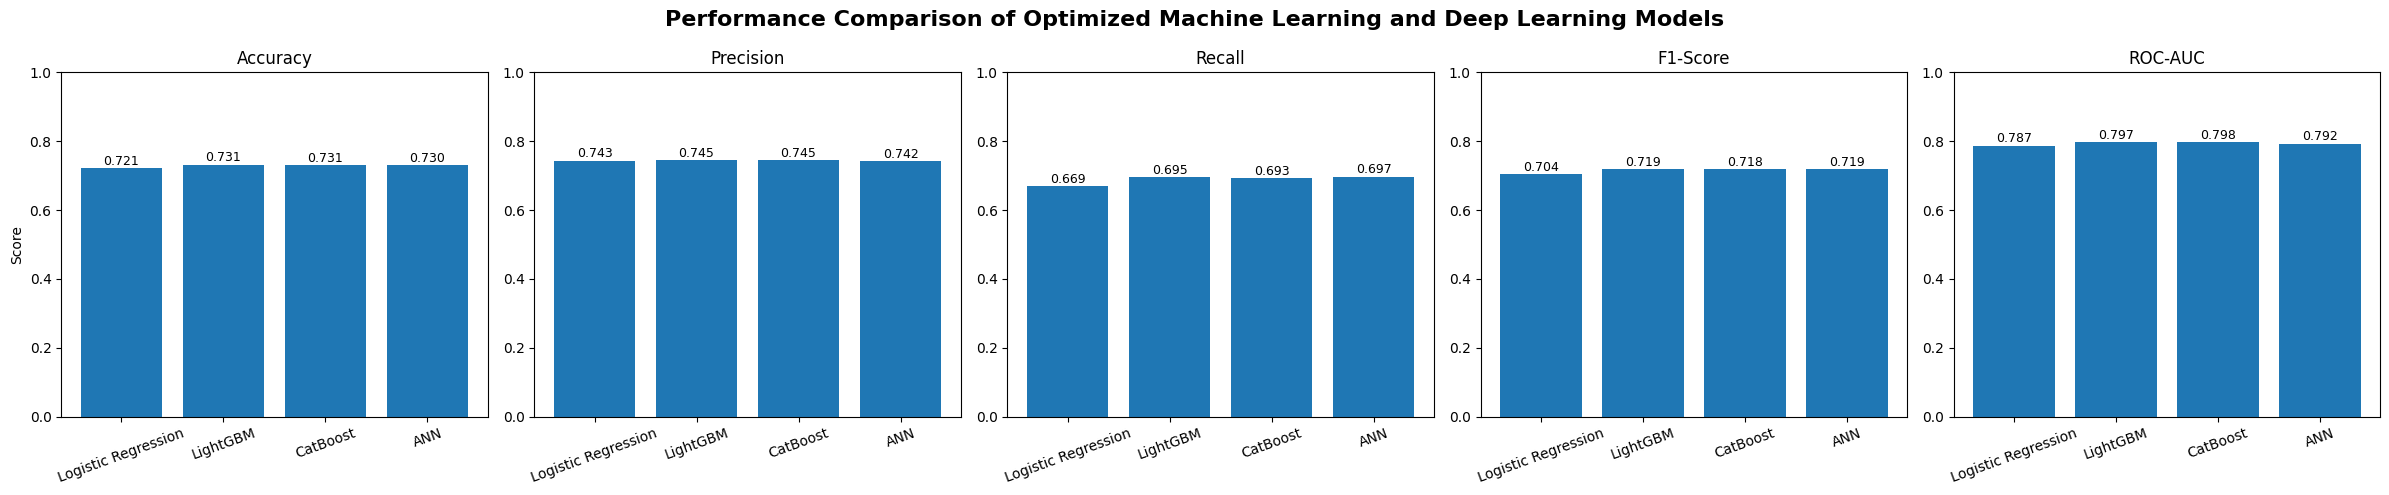

In [35]:
# Import the required libraries.
import matplotlib.pyplot as plt

# Define the model names.
models = [
    tuned_lr_metrics["Model"],
    tuned_lgbm_metrics["Model"],
    tuned_cat_metrics["Model"],
    tuned_ann_metrics["Model"]
]

# Store the evaluation metrics.
accuracy = [
    tuned_lr_metrics["Accuracy"],
    tuned_lgbm_metrics["Accuracy"],
    tuned_cat_metrics["Accuracy"],
    tuned_ann_metrics["Accuracy"]
]

precision = [
    tuned_lr_metrics["Precision"],
    tuned_lgbm_metrics["Precision"],
    tuned_cat_metrics["Precision"],
    tuned_ann_metrics["Precision"]
]

recall = [
    tuned_lr_metrics["Recall"],
    tuned_lgbm_metrics["Recall"],
    tuned_cat_metrics["Recall"],
    tuned_ann_metrics["Recall"]
]

f1 = [
    tuned_lr_metrics["F1-Score"],
    tuned_lgbm_metrics["F1-Score"],
    tuned_cat_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

roc_auc = [
    tuned_lr_metrics["ROC-AUC"],
    tuned_lgbm_metrics["ROC-AUC"],
    tuned_cat_metrics["ROC-AUC"],
    tuned_ann_metrics["ROC-AUC"]
]

# Create the figure.
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

# Accuracy
axes[0].bar(models, accuracy)
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

for i, v in enumerate(accuracy):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

# Precision
axes[1].bar(models, precision)
axes[1].set_title("Precision")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

for i, v in enumerate(precision):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

# Recall
axes[2].bar(models, recall)
axes[2].set_title("Recall")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=20)

for i, v in enumerate(recall):
    axes[2].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

# F1-Score
axes[3].bar(models, f1)
axes[3].set_title("F1-Score")
axes[3].set_ylim(0, 1)
axes[3].tick_params(axis='x', rotation=20)

for i, v in enumerate(f1):
    axes[3].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

# ROC-AUC
axes[4].bar(models, roc_auc)
axes[4].set_title("ROC-AUC")
axes[4].set_ylim(0, 1)
axes[4].tick_params(axis='x', rotation=20)

for i, v in enumerate(roc_auc):
    axes[4].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

plt.suptitle(
    "Performance Comparison of Optimized Machine Learning and Deep Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Combined Comparative Bar Graph for all Tuned Models 

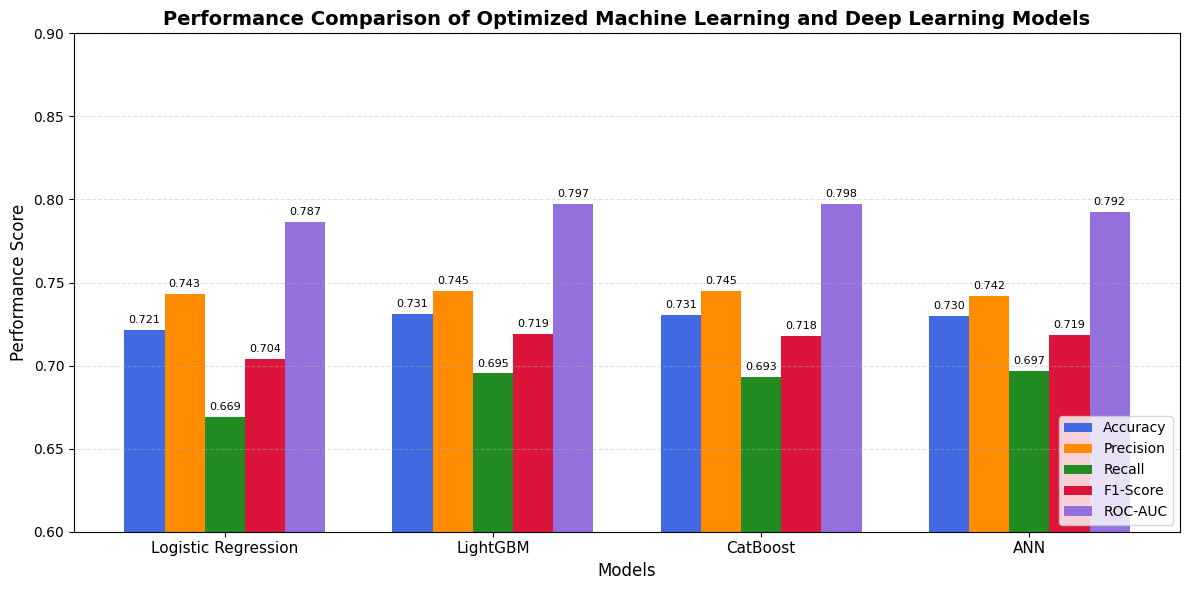

In [37]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# Define the model names.
models = [
    tuned_lr_metrics["Model"],
    tuned_lgbm_metrics["Model"],
    tuned_cat_metrics["Model"],
    tuned_ann_metrics["Model"]
]

# Store the evaluation metrics.
accuracy = [
    tuned_lr_metrics["Accuracy"],
    tuned_lgbm_metrics["Accuracy"],
    tuned_cat_metrics["Accuracy"],
    tuned_ann_metrics["Accuracy"]
]

precision = [
    tuned_lr_metrics["Precision"],
    tuned_lgbm_metrics["Precision"],
    tuned_cat_metrics["Precision"],
    tuned_ann_metrics["Precision"]
]

recall = [
    tuned_lr_metrics["Recall"],
    tuned_lgbm_metrics["Recall"],
    tuned_cat_metrics["Recall"],
    tuned_ann_metrics["Recall"]
]

f1_score = [
    tuned_lr_metrics["F1-Score"],
    tuned_lgbm_metrics["F1-Score"],
    tuned_cat_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

roc_auc = [
    tuned_lr_metrics["ROC-AUC"],
    tuned_lgbm_metrics["ROC-AUC"],
    tuned_cat_metrics["ROC-AUC"],
    tuned_ann_metrics["ROC-AUC"]
]

# Set the bar positions.
x = np.arange(len(models))

width = 0.15

# Create the figure.
plt.figure(figsize=(12,6))

bars1 = plt.bar(x - 2*width, accuracy, width, label="Accuracy", color="royalblue")
bars2 = plt.bar(x - width, precision, width, label="Precision", color="darkorange")
bars3 = plt.bar(x, recall, width, label="Recall", color="forestgreen")
bars4 = plt.bar(x + width, f1_score, width, label="F1-Score", color="crimson")
bars5 = plt.bar(x + 2*width, roc_auc, width, label="ROC-AUC", color="mediumpurple")

# Add value labels.
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Customize the graph.
plt.xticks(x, models, fontsize=11)

plt.yticks(fontsize=10)

plt.ylim(0.60, 0.90)

plt.ylabel("Performance Score", fontsize=12)

plt.xlabel("Models", fontsize=12)

plt.title(
    "Performance Comparison of Optimized Machine Learning and Deep Learning Models",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(loc="lower right", fontsize=10)

plt.tight_layout()

plt.show()

# Combined F1-Score Graph for all Tuned Models 

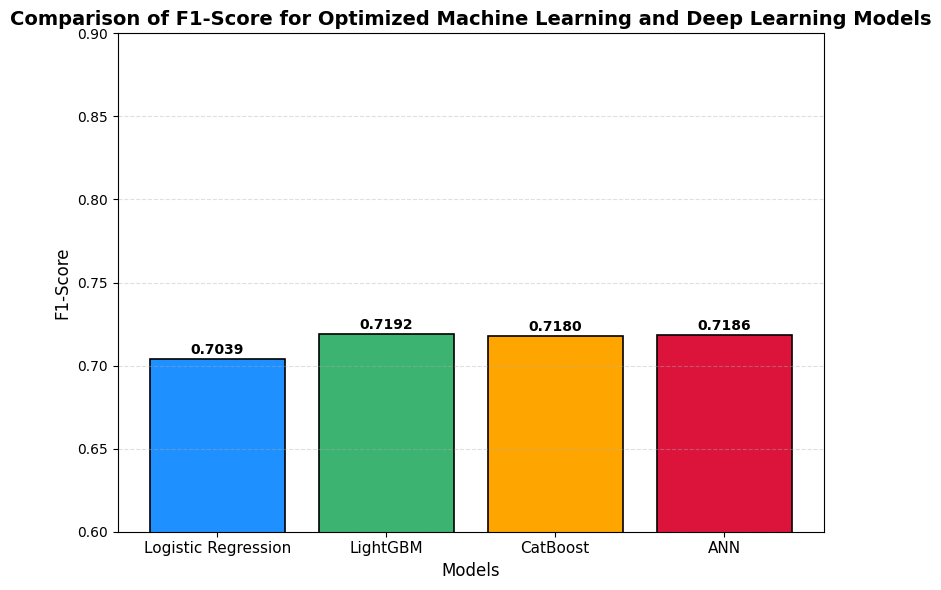

In [38]:
# Import the required libraries.
import matplotlib.pyplot as plt

# Define the model names.
models = [
    tuned_lr_metrics["Model"],
    tuned_lgbm_metrics["Model"],
    tuned_cat_metrics["Model"],
    tuned_ann_metrics["Model"]
]

# Store the F1-Score values.
f1_scores = [
    tuned_lr_metrics["F1-Score"],
    tuned_lgbm_metrics["F1-Score"],
    tuned_cat_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

# Define different colors for each model.
colors = [
    "dodgerblue",
    "mediumseagreen",
    "orange",
    "crimson"
]

# Create the figure.
plt.figure(figsize=(8,6))

bars = plt.bar(
    models,
    f1_scores,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# Add value labels.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Customize the graph.
plt.title(
    "Comparison of F1-Score for Optimized Machine Learning and Deep Learning Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Models", fontsize=12)

plt.ylabel("F1-Score", fontsize=12)

plt.ylim(0.60, 0.90)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(fontsize=11)

plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()

# Confusion Matrices for all Tuned Models 

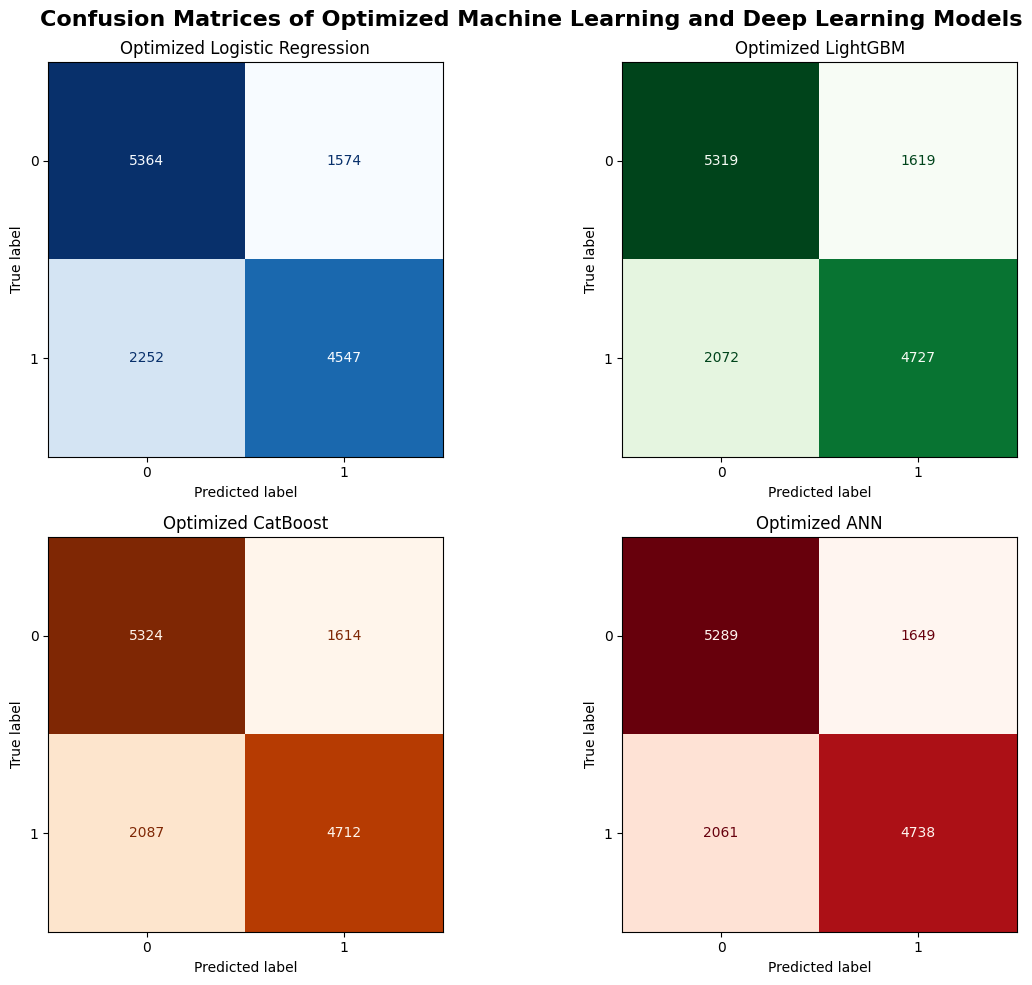

In [39]:
# Import the required libraries.
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create the figure.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix=tuned_lr_metrics["Confusion Matrix"]
).plot(
    ax=axes[0, 0],
    cmap="Blues",
    colorbar=False
)

axes[0, 0].set_title("Optimized Logistic Regression")

# LightGBM
ConfusionMatrixDisplay(
    confusion_matrix=tuned_lgbm_metrics["Confusion Matrix"]
).plot(
    ax=axes[0, 1],
    cmap="Greens",
    colorbar=False
)

axes[0, 1].set_title("Optimized LightGBM")

# CatBoost
ConfusionMatrixDisplay(
    confusion_matrix=tuned_cat_metrics["Confusion Matrix"]
).plot(
    ax=axes[1, 0],
    cmap="Oranges",
    colorbar=False
)

axes[1, 0].set_title("Optimized CatBoost")

# ANN
ConfusionMatrixDisplay(
    confusion_matrix=tuned_ann_metrics["Confusion Matrix"]
).plot(
    ax=axes[1, 1],
    cmap="Reds",
    colorbar=False
)

axes[1, 1].set_title("Optimized ANN")

# Add the main title.
plt.suptitle(
    "Confusion Matrices of Optimized Machine Learning and Deep Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Combined AUC-ROC Curve for all Tuned Models 

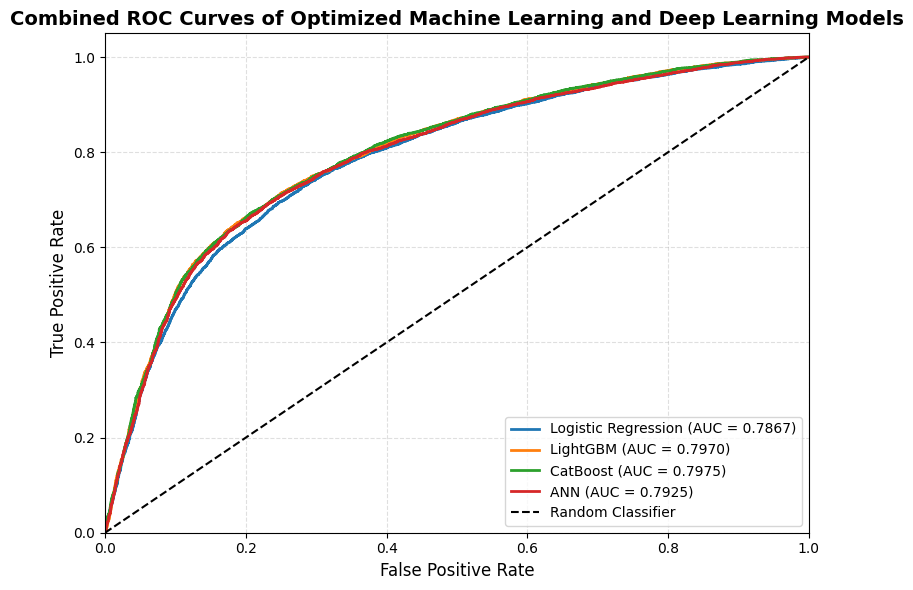

In [40]:
# Import the required libraries.
import matplotlib.pyplot as plt

# Create the figure.
plt.figure(figsize=(8, 6))

# Plot the ROC curve for Logistic Regression.
plt.plot(
    tuned_lr_metrics["FPR"],
    tuned_lr_metrics["TPR"],
    linewidth=2,
    label=f'Logistic Regression (AUC = {tuned_lr_metrics["ROC-AUC"]:.4f})'
)

# Plot the ROC curve for LightGBM.
plt.plot(
    tuned_lgbm_metrics["FPR"],
    tuned_lgbm_metrics["TPR"],
    linewidth=2,
    label=f'LightGBM (AUC = {tuned_lgbm_metrics["ROC-AUC"]:.4f})'
)

# Plot the ROC curve for CatBoost.
plt.plot(
    tuned_cat_metrics["FPR"],
    tuned_cat_metrics["TPR"],
    linewidth=2,
    label=f'CatBoost (AUC = {tuned_cat_metrics["ROC-AUC"]:.4f})'
)

# Plot the ROC curve for ANN.
plt.plot(
    tuned_ann_metrics["FPR"],
    tuned_ann_metrics["TPR"],
    linewidth=2,
    label=f'ANN (AUC = {tuned_ann_metrics["ROC-AUC"]:.4f})'
)

# Plot the random classifier line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

# Customize the graph.
plt.title(
    "Combined ROC Curves of Optimized Machine Learning and Deep Learning Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("False Positive Rate", fontsize=12)

plt.ylabel("True Positive Rate", fontsize=12)

plt.xlim([0.0, 1.0])

plt.ylim([0.0, 1.05])

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(loc="lower right", fontsize=10)

plt.tight_layout()

plt.show()

# Combined Comparative Table for all Baseline and Tuned Models 

In [41]:
# Import the required library.
import pandas as pd

# Add the model type.
baseline_table = baseline_results.copy()
baseline_table["Model Type"] = "Baseline"

tuned_table = tuned_results.copy()
tuned_table["Model Type"] = "Optimized"

# Combine the tables.
comparison_table = pd.concat(
    [baseline_table, tuned_table],
    ignore_index=True
)

# Arrange the columns.
comparison_table = comparison_table[
    [
        "Model Type",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

# Round the metric values.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_table[metric_columns] = comparison_table[metric_columns].round(4)

# Display the table.
display(
    comparison_table.style
    .hide(axis="index")
    .set_caption(
        "Table: Comparative Performance of Baseline and Optimized Machine Learning and Deep Learning Models"
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        }
    ])
    .background_gradient(
        cmap="YlGn",
        subset=metric_columns
    )
)

Model Type,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Baseline,Baseline Logistic Regression,0.721500,0.723400,0.721500,0.720700,0.786700
Baseline,Baseline LightGBM,0.730700,0.731500,0.730700,0.730400,0.797500
Baseline,Baseline CatBoost,0.730700,0.731700,0.730700,0.730300,0.798300
Baseline,Baseline ANN,0.724700,0.725100,0.724700,0.724400,0.788100
Optimized,Logistic Regression,0.721500,0.742900,0.668800,0.703900,0.786700
Optimized,LightGBM,0.731300,0.744900,0.695200,0.719200,0.797000
Optimized,CatBoost,0.730600,0.744900,0.693000,0.718000,0.797500
Optimized,ANN,0.729900,0.741800,0.696900,0.718600,0.792500


# Combined Comparative F1-Score Graph for all Baseline and Tuned Models 

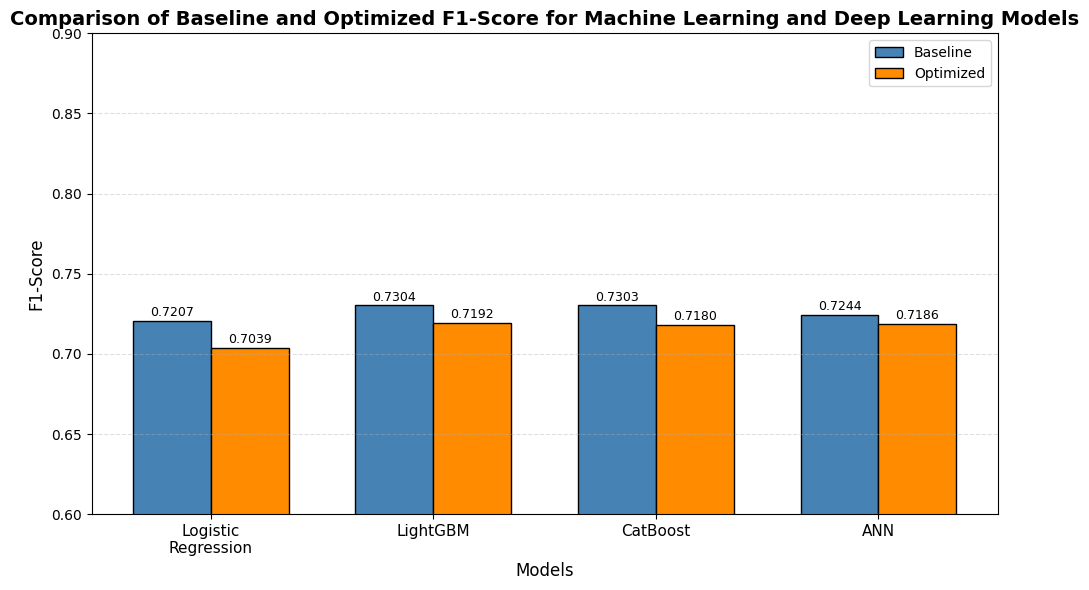

In [43]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# Define the model names.
models = [
    "Logistic\nRegression",
    "LightGBM",
    "CatBoost",
    "ANN"
]

# Store the baseline F1-Score values.
baseline_f1 = [
    bas_lr_metrics["F1-Score"],
    bas_lgbm_metrics["F1-Score"],
    bas_cat_metrics["F1-Score"],
    bas_ann_metrics["F1-Score"]
]

# Store the optimized F1-Score values.
tuned_f1 = [
    tuned_lr_metrics["F1-Score"],
    tuned_lgbm_metrics["F1-Score"],
    tuned_cat_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

# Set the bar positions.
x = np.arange(len(models))
width = 0.35

# Create the figure.
plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    baseline_f1,
    width,
    label="Baseline",
    color="steelblue",
    edgecolor="black"
)

bars2 = plt.bar(
    x + width/2,
    tuned_f1,
    width,
    label="Optimized",
    color="darkorange",
    edgecolor="black"
)

# Add value labels.
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=9
    )

# Customize the graph.
plt.xticks(x, models, fontsize=11)

plt.ylabel("F1-Score", fontsize=12)

plt.xlabel("Models", fontsize=12)

plt.ylim(0.60, 0.90)

plt.title(
    "Comparison of Baseline and Optimized F1-Score for Machine Learning and Deep Learning Models",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(fontsize=10)

plt.tight_layout()

plt.show()

# Combined Comparative Bar Graph for all Baseline and Tuned Models 

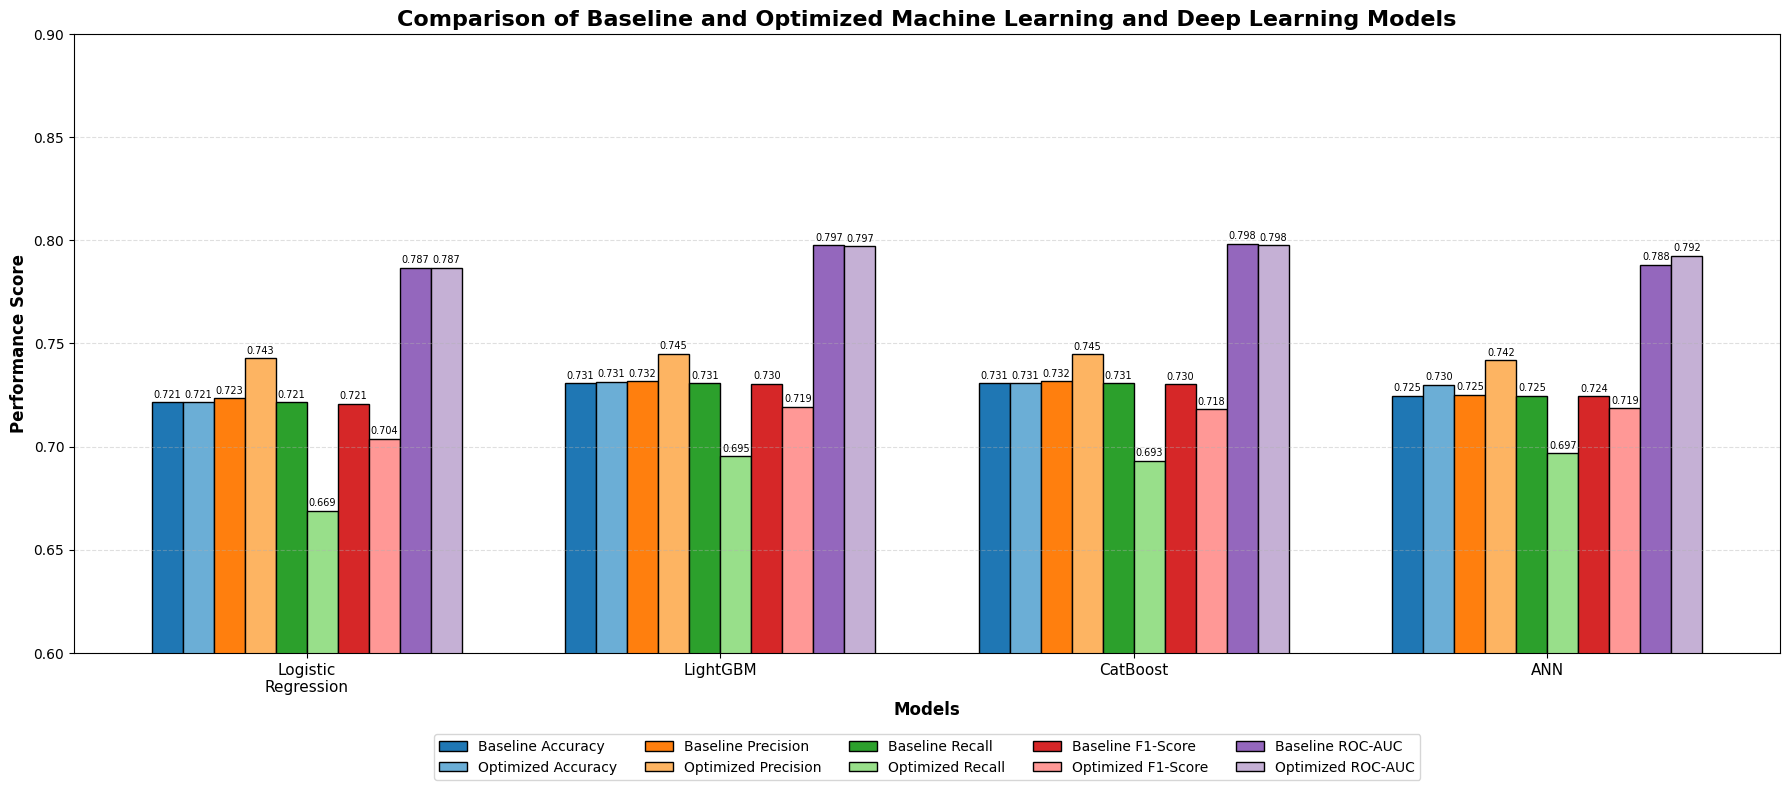

In [44]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# Define the model names.
models = [
    "Logistic\nRegression",
    "LightGBM",
    "CatBoost",
    "ANN"
]

# Baseline metrics.
baseline_accuracy = [
    bas_lr_metrics["Accuracy"],
    bas_lgbm_metrics["Accuracy"],
    bas_cat_metrics["Accuracy"],
    bas_ann_metrics["Accuracy"]
]

baseline_precision = [
    bas_lr_metrics["Precision"],
    bas_lgbm_metrics["Precision"],
    bas_cat_metrics["Precision"],
    bas_ann_metrics["Precision"]
]

baseline_recall = [
    bas_lr_metrics["Recall"],
    bas_lgbm_metrics["Recall"],
    bas_cat_metrics["Recall"],
    bas_ann_metrics["Recall"]
]

baseline_f1 = [
    bas_lr_metrics["F1-Score"],
    bas_lgbm_metrics["F1-Score"],
    bas_cat_metrics["F1-Score"],
    bas_ann_metrics["F1-Score"]
]

baseline_auc = [
    bas_lr_metrics["ROC-AUC"],
    bas_lgbm_metrics["ROC-AUC"],
    bas_cat_metrics["ROC-AUC"],
    bas_ann_metrics["ROC-AUC"]
]

# Optimized metrics.
optimized_accuracy = [
    tuned_lr_metrics["Accuracy"],
    tuned_lgbm_metrics["Accuracy"],
    tuned_cat_metrics["Accuracy"],
    tuned_ann_metrics["Accuracy"]
]

optimized_precision = [
    tuned_lr_metrics["Precision"],
    tuned_lgbm_metrics["Precision"],
    tuned_cat_metrics["Precision"],
    tuned_ann_metrics["Precision"]
]

optimized_recall = [
    tuned_lr_metrics["Recall"],
    tuned_lgbm_metrics["Recall"],
    tuned_cat_metrics["Recall"],
    tuned_ann_metrics["Recall"]
]

optimized_f1 = [
    tuned_lr_metrics["F1-Score"],
    tuned_lgbm_metrics["F1-Score"],
    tuned_cat_metrics["F1-Score"],
    tuned_ann_metrics["F1-Score"]
]

optimized_auc = [
    tuned_lr_metrics["ROC-AUC"],
    tuned_lgbm_metrics["ROC-AUC"],
    tuned_cat_metrics["ROC-AUC"],
    tuned_ann_metrics["ROC-AUC"]
]

# Set the positions.
x = np.arange(len(models))
width = 0.075

# Create the figure.
plt.figure(figsize=(18, 8))

# Plot the bars with different colors.
plt.bar(x-4.5*width, baseline_accuracy, width,
        color="#1F77B4", edgecolor="black",
        label="Baseline Accuracy")

plt.bar(x-3.5*width, optimized_accuracy, width,
        color="#6BAED6", edgecolor="black",
        label="Optimized Accuracy")

plt.bar(x-2.5*width, baseline_precision, width,
        color="#FF7F0E", edgecolor="black",
        label="Baseline Precision")

plt.bar(x-1.5*width, optimized_precision, width,
        color="#FDB462", edgecolor="black",
        label="Optimized Precision")

plt.bar(x-0.5*width, baseline_recall, width,
        color="#2CA02C", edgecolor="black",
        label="Baseline Recall")

plt.bar(x+0.5*width, optimized_recall, width,
        color="#98DF8A", edgecolor="black",
        label="Optimized Recall")

plt.bar(x+1.5*width, baseline_f1, width,
        color="#D62728", edgecolor="black",
        label="Baseline F1-Score")

plt.bar(x+2.5*width, optimized_f1, width,
        color="#FF9896", edgecolor="black",
        label="Optimized F1-Score")

plt.bar(x+3.5*width, baseline_auc, width,
        color="#9467BD", edgecolor="black",
        label="Baseline ROC-AUC")

plt.bar(x+4.5*width, optimized_auc, width,
        color="#C5B0D5", edgecolor="black",
        label="Optimized ROC-AUC")

# Add value labels.
for bars in plt.gca().containers:
    plt.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

# Customize the graph.
plt.xticks(x, models, fontsize=11)

plt.xlabel("Models", fontsize=12, fontweight="bold")

plt.ylabel("Performance Score", fontsize=12, fontweight="bold")

plt.title(
    "Comparison of Baseline and Optimized Machine Learning and Deep Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.ylim(0.60, 0.90)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=10,
    frameon=True
)

plt.tight_layout()

plt.show()

# Best Performing Model 

In [45]:
# Import the required library.
import pandas as pd

# Store all baseline and optimized models.
all_models = [
    {
        "Version": "Baseline",
        **bas_lr_metrics
    },
    {
        "Version": "Baseline",
        **bas_lgbm_metrics
    },
    {
        "Version": "Baseline",
        **bas_cat_metrics
    },
    {
        "Version": "Baseline",
        **bas_ann_metrics
    },
    {
        "Version": "Optimized",
        **tuned_lr_metrics
    },
    {
        "Version": "Optimized",
        **tuned_lgbm_metrics
    },
    {
        "Version": "Optimized",
        **tuned_cat_metrics
    },
    {
        "Version": "Optimized",
        **tuned_ann_metrics
    }
]

# Create the comparison table.
comparison_df = pd.DataFrame(all_models)

# Keep only the required columns.
comparison_df = comparison_df[
    [
        "Version",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

# Round the values.
comparison_df = comparison_df.round(4)

# Find the best model based on F1-Score.
best_index = comparison_df["F1-Score"].idxmax()
best_model = comparison_df.loc[best_index]

# Display the comparison table.
display(
    comparison_df.style
    .hide(axis="index")
    .set_caption(
        "Comparison of Baseline and Optimized Machine Learning and Deep Learning Models"
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        }
    ])
    .background_gradient(
        cmap="YlGn",
        subset=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC"
        ]
    )
    .highlight_max(
        subset=["F1-Score"],
        color="lightgreen"
    )
)

# Display the best model.

print("BEST PERFORMING MODEL BASED ON F1-SCORE")

print(f"Model Version : {best_model['Version']}")
print(f"Model Name    : {best_model['Model']}")
print(f"Accuracy      : {best_model['Accuracy']:.4f}")
print(f"Precision     : {best_model['Precision']:.4f}")
print(f"Recall        : {best_model['Recall']:.4f}")
print(f"F1-Score      : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC       : {best_model['ROC-AUC']:.4f}")



# Display the ranking based on F1-Score.
ranking = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

ranking.index = ranking.index + 1

print("\nRanking of All Models Based on F1-Score\n")
display(ranking)

Version,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Baseline,Baseline Logistic Regression,0.721500,0.723400,0.721500,0.720700,0.786700
Baseline,Baseline LightGBM,0.730700,0.731500,0.730700,0.730400,0.797500
Baseline,Baseline CatBoost,0.730700,0.731700,0.730700,0.730300,0.798300
Baseline,Baseline ANN,0.724700,0.725100,0.724700,0.724400,0.788100
Optimized,Logistic Regression,0.721500,0.742900,0.668800,0.703900,0.786700
Optimized,LightGBM,0.731300,0.744900,0.695200,0.719200,0.797000
Optimized,CatBoost,0.730600,0.744900,0.693000,0.718000,0.797500
Optimized,ANN,0.729900,0.741800,0.696900,0.718600,0.792500


BEST PERFORMING MODEL BASED ON F1-SCORE
Model Version : Baseline
Model Name    : Baseline LightGBM
Accuracy      : 0.7307
Precision     : 0.7315
Recall        : 0.7307
F1-Score      : 0.7304
ROC-AUC       : 0.7975

Ranking of All Models Based on F1-Score



,Version,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Baseline,Baseline LightGBM,0.7307,0.7315,0.7307,0.7304,0.7975
2,Baseline,Baseline CatBoost,0.7307,0.7317,0.7307,0.7303,0.7983
3,Baseline,Baseline ANN,0.7247,0.7251,0.7247,0.7244,0.7881
4,Baseline,Baseline Logistic Regression,0.7215,0.7234,0.7215,0.7207,0.7867
5,Optimized,LightGBM,0.7313,0.7449,0.6952,0.7192,0.7970
6,Optimized,ANN,0.7299,0.7418,0.6969,0.7186,0.7925
7,Optimized,CatBoost,0.7306,0.7449,0.6930,0.7180,0.7975
8,Optimized,Logistic Regression,0.7215,0.7429,0.6688,0.7039,0.7867


# Saving the Best Model for Further Analysis 

In [46]:
# Import the required library.
import joblib

# Save the trained best LightGBM model.
joblib.dump(bas_lgbm_model, "cardio_best_lightgbm_model.pkl")

# Save the fitted StandardScaler.
joblib.dump(scaler, "cardio_standard_scaler.pkl")

# Save the feature names used for training.
joblib.dump(list(X_train.columns), "cardio_feature_names.pkl")

['cardio_feature_names.pkl']

# SHAP Analysis 

In [ ]:
!pip install shap

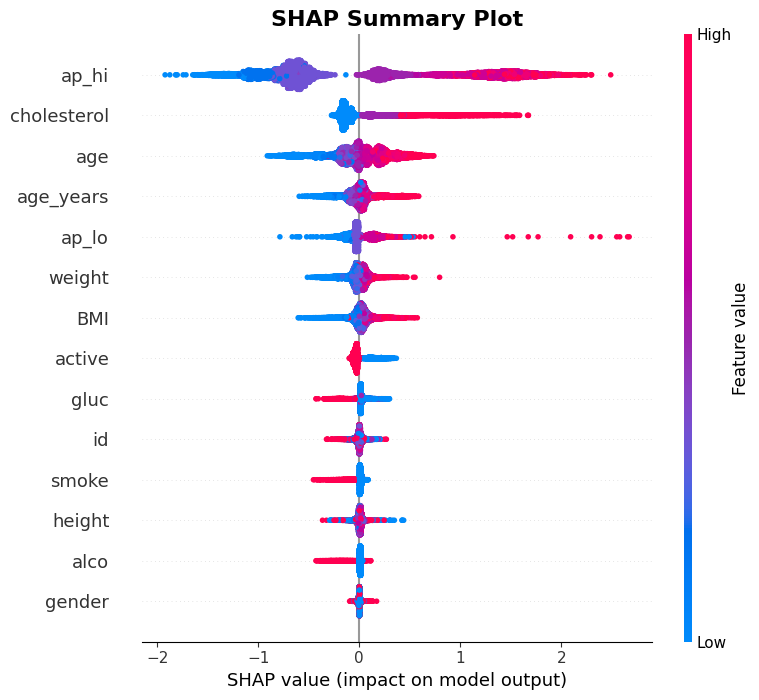

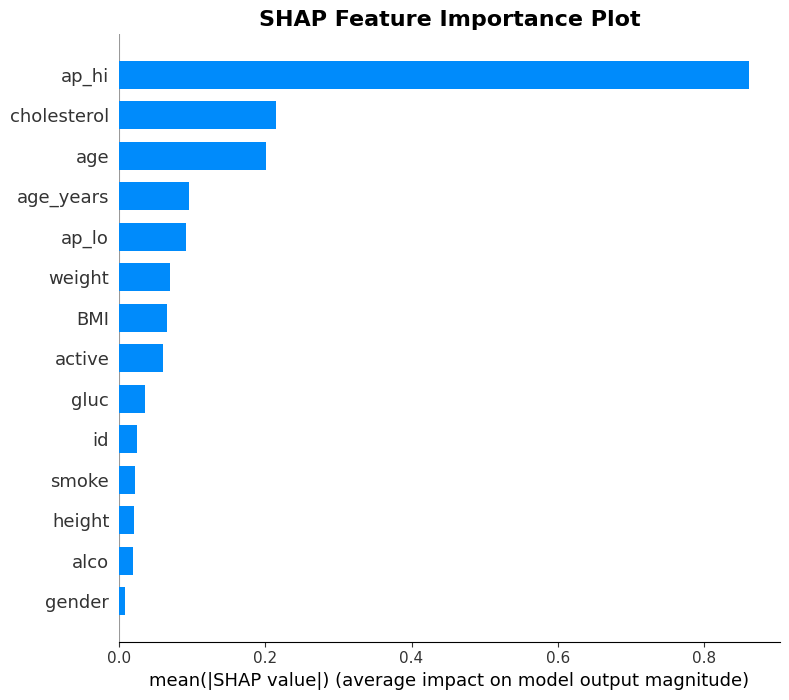

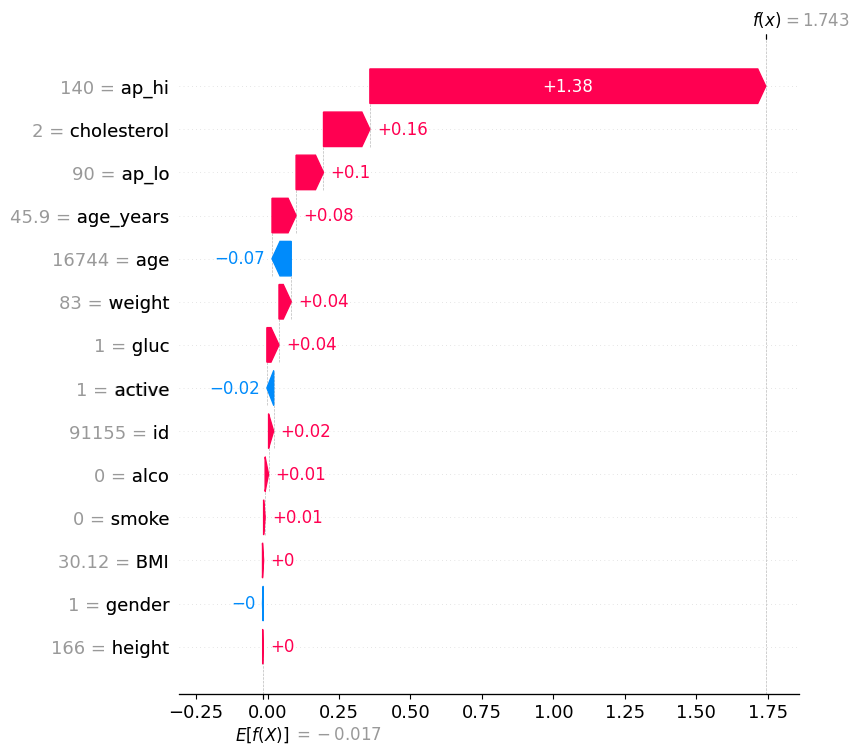

Most Important Feature: ap_hi


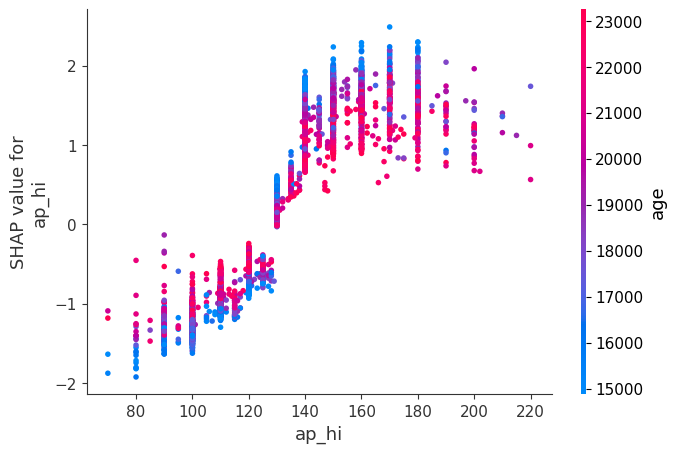

In [51]:
# Import the required libraries.
import shap
import numpy as np
import matplotlib.pyplot as plt

# Initialize SHAP.
shap.initjs()

# Create the SHAP explainer.
explainer = shap.TreeExplainer(bas_lgbm_model)
import warnings

warnings.filterwarnings(
    "ignore",
    message="LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray*"
)
# Calculate SHAP values.
shap_values = explainer.shap_values(X_test)

# Handle different SHAP versions.
if isinstance(shap_values, list):
    shap_array = shap_values[1]
    base_value = explainer.expected_value[1]
else:
    shap_array = shap_values
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_value = explainer.expected_value[0]
    else:
        base_value = explainer.expected_value


# SHAP Summary Plot


plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_array,
    X_test,
    show=False
)

plt.title(
    "SHAP Summary Plot",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# SHAP Feature Importance Plot


plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_array,
    X_test,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Feature Importance Plot",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()



# SHAP Waterfall Plot


waterfall_values = shap.Explanation(

    values=shap_array[0],

    base_values=base_value,

    data=X_test.iloc[0],

    feature_names=X_test.columns

)

shap.plots.waterfall(
    waterfall_values,
    max_display=15
)



# SHAP Dependence Plot


feature_importance = np.abs(shap_array).mean(axis=0)

top_feature = X_test.columns[np.argmax(feature_importance)]

print("Most Important Feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_array,
    X_test,
    interaction_index="auto"
)

Instance,Actual Class,Predicted Class,Probability (Class 0),Probability (Class 1),Prediction Status
0,1,1,0.149000,0.851000,Correct


Feature,Contribution
120.00 < ap_hi <= 140.00,0.176719
cholesterol > 1.00,0.151001
alco <= 0.00,0.046645
weight > 82.00,0.044222
80.00 < ap_lo <= 90.00,0.032135
smoke <= 0.00,0.027628
gluc <= 1.00,0.011493
BMI > 30.12,0.010929
age_years <= 48.40,-0.029965
age <= 17655.00,-0.055955


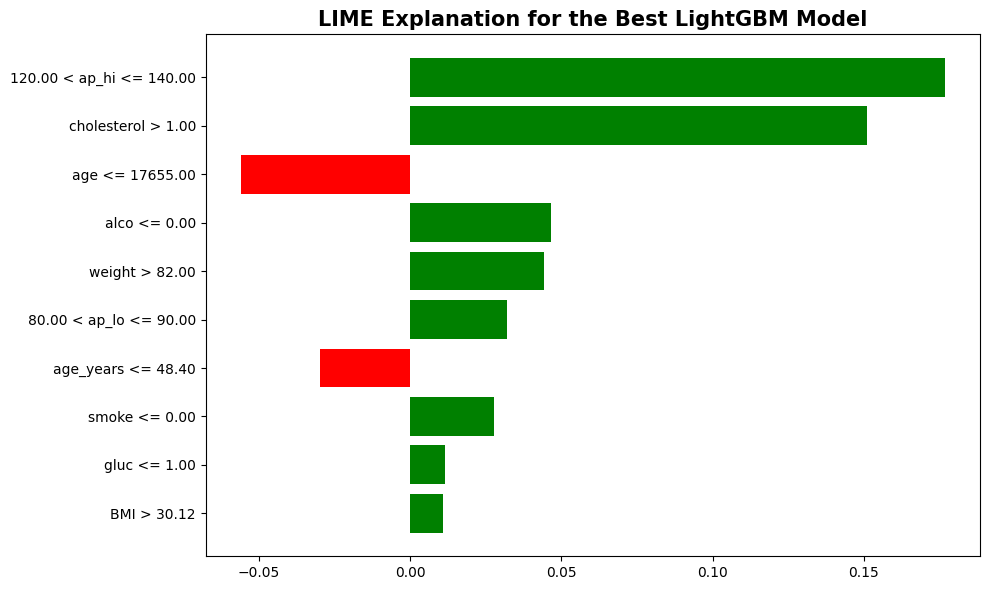

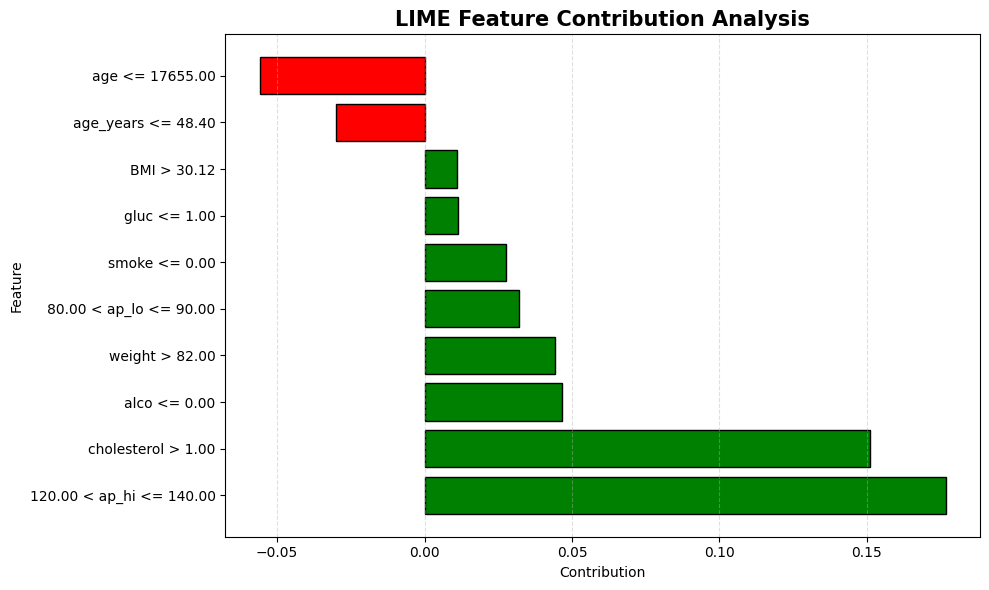

Feature,Contribution
120.00 < ap_hi <= 140.00,0.176719
cholesterol > 1.00,0.151001
alco <= 0.00,0.046645
weight > 82.00,0.044222
80.00 < ap_lo <= 90.00,0.032135
smoke <= 0.00,0.027628
gluc <= 1.00,0.011493
BMI > 30.12,0.010929


Feature,Contribution
age_years <= 48.40,-0.029965
age <= 17655.00,-0.055955


In [55]:
# Import the required libraries.
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create the LIME explainer.
lime_explainer = LimeTabularExplainer(

    training_data=np.array(X_train),

    feature_names=X_train.columns,

    class_names=[
        "No Cardiovascular Disease",
        "Cardiovascular Disease"
    ],

    mode="classification",

    discretize_continuous=True,

    random_state=42

)

# Select the instance to explain.
instance_index = 0

# Generate the explanation.
lime_exp = lime_explainer.explain_instance(

    data_row=X_test.iloc[instance_index],

    predict_fn=bas_lgbm_model.predict_proba,

    num_features=10

)

# Predict the class.
predicted_class = bas_lgbm_model.predict(
    X_test.iloc[[instance_index]]
)[0]

# Predict the probabilities.
prediction_probability = bas_lgbm_model.predict_proba(
    X_test.iloc[[instance_index]]
)[0]

# Actual class.
actual_class = y_test.iloc[instance_index]

# Display the prediction summary.
summary_df = pd.DataFrame({

    "Instance":[instance_index],

    "Actual Class":[actual_class],

    "Predicted Class":[predicted_class],

    "Probability (Class 0)":[round(prediction_probability[0],4)],

    "Probability (Class 1)":[round(prediction_probability[1],4)],

    "Prediction Status":[
        "Correct" if actual_class == predicted_class else "Incorrect"
    ]

})

display(

    summary_df.style
    .hide(axis="index")
    .set_caption("LIME Prediction Summary")
    .set_table_styles([
        {
            "selector":"caption",
            "props":[
                ("font-size","16px"),
                ("font-weight","bold"),
                ("text-align","center")
            ]
        },
        {
            "selector":"th",
            "props":[
                ("background-color","#1F4E78"),
                ("color","white"),
                ("text-align","center"),
                ("border","1px solid black")
            ]
        },
        {
            "selector":"td",
            "props":[
                ("text-align","center"),
                ("border","1px solid black")
            ]
        }
    ])

)

# Create the feature contribution table.
lime_results = pd.DataFrame(

    lime_exp.as_list(),

    columns=[
        "Feature",
        "Contribution"
    ]

)

# Sort the contributions.
lime_results = lime_results.sort_values(

    by="Contribution",

    ascending=False

)

# Display the feature contributions.
display(

    lime_results.style
    .hide(axis="index")
    .set_caption("LIME Feature Contributions")
    .background_gradient(
        cmap="RdYlGn",
        subset=["Contribution"]
    )
    .set_table_styles([
        {
            "selector":"caption",
            "props":[
                ("font-size","16px"),
                ("font-weight","bold"),
                ("text-align","center")
            ]
        },
        {
            "selector":"th",
            "props":[
                ("background-color","#1F4E78"),
                ("color","white"),
                ("text-align","center"),
                ("border","1px solid black")
            ]
        },
        {
            "selector":"td",
            "props":[
                ("text-align","center"),
                ("border","1px solid black")
            ]
        }
    ])

)

# Plot the LIME explanation.
fig = lime_exp.as_pyplot_figure()

fig.set_size_inches(10,6)

plt.title(

    "LIME Explanation for the Best LightGBM Model",

    fontsize=15,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

# Plot the feature contributions.
plt.figure(figsize=(10,6))

colors = [

    "green" if value > 0 else "red"

    for value in lime_results["Contribution"]

]

plt.barh(

    lime_results["Feature"],

    lime_results["Contribution"],

    color=colors,

    edgecolor="black"

)

plt.xlabel("Contribution")

plt.ylabel("Feature")

plt.title(

    "LIME Feature Contribution Analysis",

    fontsize=15,

    fontweight="bold"

)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Display the positive contributors.
positive_features = lime_results[lime_results["Contribution"] > 0]

display(

    positive_features.style
    .hide(axis="index")
    .set_caption("Top Positive Feature Contributions")

)

# Display the negative contributors.
negative_features = lime_results[lime_results["Contribution"] < 0]

display(

    negative_features.style
    .hide(axis="index")
    .set_caption("Top Negative Feature Contributions")

)

# Interface For Human Evaluation 

In [63]:
import tkinter as tk
from tkinter import ttk, messagebox, filedialog
from tkinter.scrolledtext import ScrolledText
import pandas as pd
import joblib
from datetime import datetime

MODEL_FILE = "cardio_best_lightgbm_model.pkl"

try:
    model = joblib.load(MODEL_FILE)
except Exception:
    model = None

root = tk.Tk()
root.title("🏥 Cardiovascular Disease Prediction System")
root.geometry("1200x820")
root.configure(bg="#EAF6FB")

style = ttk.Style()
style.theme_use("clam")
style.configure("TButton", font=("Segoe UI",10,"bold"), padding=6)
style.configure("TLabel", background="#EAF6FB", font=("Segoe UI",10))
style.configure("Header.TLabel", font=("Segoe UI",20,"bold"),
                background="#0077B6", foreground="white")

banner = tk.Frame(root,bg="#0077B6",height=70)
banner.pack(fill="x")
ttk.Label(banner,text="❤ Cardiovascular Disease Prediction Prototype",
          style="Header.TLabel").pack(pady=18)

canvas=tk.Canvas(root,bg="#EAF6FB",highlightthickness=0)
scroll=ttk.Scrollbar(root,orient="vertical",command=canvas.yview)
frame=tk.Frame(canvas,bg="#EAF6FB")
frame.bind("<Configure>",lambda e:canvas.configure(scrollregion=canvas.bbox("all")))
canvas.create_window((0,0),window=frame,anchor="nw")
canvas.configure(yscrollcommand=scroll.set)
canvas.pack(side="left",fill="both",expand=True)
scroll.pack(side="right",fill="y")

fields={}
def entry(parent,text,row):
    ttk.Label(parent,text=text).grid(row=row,column=0,padx=5,pady=5,sticky="w")
    e=ttk.Entry(parent,width=28)
    e.grid(row=row,column=1,padx=5,pady=5)
    fields[text]=e

def combo(parent,text,row,vals):
    ttk.Label(parent,text=text).grid(row=row,column=0,padx=5,pady=5,sticky="w")
    c=ttk.Combobox(parent,values=vals,state="readonly",width=25)
    c.current(0)
    c.grid(row=row,column=1,padx=5,pady=5)
    fields[text]=c

patient=ttk.LabelFrame(frame,text="Patient Information")
patient.pack(fill="x",padx=15,pady=10)

entry(patient,"ID",0)
entry(patient,"Age (Years)",1)
combo(patient,"Gender",2,["1 - Male","2 - Female"])
entry(patient,"Height (cm)",3)
entry(patient,"Weight (kg)",4)
entry(patient,"Systolic BP",5)
entry(patient,"Diastolic BP",6)
combo(patient,"Cholesterol",7,["1 - Normal","2 - Above Normal","3 - Well Above"])
combo(patient,"Glucose",8,["1 - Normal","2 - Above Normal","3 - Well Above"])
combo(patient,"Smoking",9,["0 - No","1 - Yes"])
combo(patient,"Alcohol",10,["0 - No","1 - Yes"])
combo(patient,"Physical Activity",11,["0 - No","1 - Yes"])

pred=tk.StringVar()
conf=tk.StringVar()
risk=tk.StringVar()
bmi_var=tk.StringVar()

history=[]

tree=None

def predict():
    if model is None:
        messagebox.showerror("Error","Model file not found.")
        return
    try:
        age_years=float(fields["Age (Years)"].get())
        age_days=age_years*365
        h=float(fields["Height (cm)"].get())
        w=float(fields["Weight (kg)"].get())
        bmi=w/((h/100)**2)
        bmi_var.set(f"{bmi:.2f}")

        vals=[[float(fields["ID"].get()),
               age_days,
               int(fields["Gender"].get()[0]),
               h,w,
               float(fields["Systolic BP"].get()),
               float(fields["Diastolic BP"].get()),
               int(fields["Cholesterol"].get()[0]),
               int(fields["Glucose"].get()[0]),
               int(fields["Smoking"].get()[0]),
               int(fields["Alcohol"].get()[0]),
               int(fields["Physical Activity"].get()[0]),
               age_years,
               bmi]]

        cols=["id","age","gender","height","weight","ap_hi","ap_lo",
              "cholesterol","gluc","smoke","alco","active","age_years","BMI"]

        X=pd.DataFrame(vals,columns=cols)

        p=model.predict(X)[0]
        pr=model.predict_proba(X)[0].max()*100

        label="Cardiovascular Disease" if p==1 else "No Cardiovascular Disease"
        pred.set(label)
        conf.set(f"{pr:.2f}%")

        if pr>=80:
            risk.set("High")
        elif pr>=60:
            risk.set("Moderate")
        else:
            risk.set("Low")

        tree.insert("",tk.END,values=(datetime.now().strftime("%Y-%m-%d %H:%M"),
                                      label,f"{pr:.2f}%"))
    except Exception as e:
        messagebox.showerror("Error",str(e))

def reset():
    for w in fields.values():
        if isinstance(w,ttk.Combobox):
            w.current(0)
        else:
            w.delete(0,tk.END)
    pred.set("")
    conf.set("")
    risk.set("")
    bmi_var.set("")
    comments.delete("1.0",tk.END)

summary=ttk.LabelFrame(frame,text="Prediction")
summary.pack(fill="x",padx=15,pady=10)

ttk.Button(summary,text="🔍 Predict",command=predict).grid(row=0,column=0,padx=5,pady=5)
ttk.Button(summary,text="♻ Reset",command=reset).grid(row=0,column=1,padx=5,pady=5)

labels=[("Prediction",pred),("Confidence",conf),("Risk",risk),("BMI",bmi_var)]
for i,(t,v) in enumerate(labels,1):
    ttk.Label(summary,text=t).grid(row=i,column=0,sticky="w")
    ttk.Label(summary,textvariable=v,font=("Segoe UI",10,"bold")).grid(row=i,column=1,sticky="w")

fb=ttk.LabelFrame(frame,text="Human Feedback")
fb.pack(fill="x",padx=15,pady=10)

ttk.Combobox(fb,values=["Excellent","Good","Average","Poor"],
             state="readonly").pack(fill="x",padx=5,pady=5)

comments=ScrolledText(fb,height=5)
comments.pack(fill="x",padx=5,pady=5)

treeframe=ttk.LabelFrame(frame,text="Prediction History")
treeframe.pack(fill="both",expand=True,padx=15,pady=10)

tree=ttk.Treeview(treeframe,columns=("Time","Prediction","Confidence"),
                  show="headings",height=10)
for c in ("Time","Prediction","Confidence"):
    tree.heading(c,text=c)
    tree.column(c,width=250)
tree.pack(fill="both",expand=True)

def export_csv():
    f=filedialog.asksaveasfilename(defaultextension=".csv")
    if not f:
        return
    rows=[tree.item(i)["values"] for i in tree.get_children()]
    pd.DataFrame(rows,columns=["Time","Prediction","Confidence"]).to_csv(f,index=False)
    messagebox.showinfo("Done","History exported successfully.")

menubar=tk.Menu(root)
fm=tk.Menu(menubar,tearoff=0)
fm.add_command(label="Export History",command=export_csv)
fm.add_separator()
fm.add_command(label="Exit",command=root.destroy)
menubar.add_cascade(label="File",menu=fm)

hm=tk.Menu(menubar,tearoff=0)
hm.add_command(label="About",
               command=lambda:messagebox.showinfo(
                   "About",
                   "Professional Cardiovascular Disease Prediction Prototype\nLightGBM Model"))
menubar.add_cascade(label="Help",menu=hm)
root.config(menu=menubar)

status=tk.Label(root,text="Ready",bg="#0077B6",fg="white",anchor="w")
status.pack(fill="x",side="bottom")

root.mainloop()
